# Path-dependency ETF Decay — Buckets backtest (production sizing)

**Sizing:** `generate_trade_plan.py` sleeve rules (`mirror_generate_trade_plan_sizing`) set **PAIR_WEIGHTS** after the tradable **UNIVERSE** is built. **Bucket 3** (simplified): each rebalance week adds **equal-split** short notionals for `fixed_usd_per_week` from YAML (`b3_weekly_short_usd` / legacy `flow_sleeve_usd_per_rebal`); integer-share dust **carries** ticker-by-ticker; core rebalance **does not** resize or cover B3.

**Borrow:** ETF short legs use **historical average** fees from sibling `etf-dashboard/data/dashboard_data.json` (`borrow_avg_annual`), merged into `BORROW_MAP` and into the screener copy used for GTP weights.

**Engine:** Weekly dead-band hedge, dynamic target gross, incremental listings — simulator with **production-derived** weights (no equal-weight or PnL/Gross+decay optimizer).


## Setup


In [294]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, requests, time, ftplib, io, os
from datetime import datetime, timezone
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

TRADING_DAYS = 252
norm_sym = lambda x: str(x).strip().upper().replace(".", "-")
print("Imports OK")


Imports OK


## Configuration


In [295]:
CFG = {
    "capital_usd":          2_000_000,
    "start_date":           "2023-01-01",
    "slippage_bps":         10,
    "ibkr_comm_per_share":  0.0035,
    "ibkr_comm_min":        0.00,
    "ibkr_comm_max_pct":    1.00,
    "fallback_borrow_rate": 0.0,
    "margin_debit_spreads": [
        (float("inf"), 0.0045),
    ],
    "credit_spread":        -0.0040,
    "enable_short_credit_income": True,
    "financing_daycount":   360,
    "skip_ftp":             False,
    "dead_band_pct":        0.02,
    "gross_dead_band_pct":  0.05,       # full position resize if portfolio gross drifts > 5% from target
    "weight_power":         1.15,       # mild convexity to lift return without aggressive concentration
    "mix_decay_weight":     0.40,       # balanced blend between realized PnL/Gross and decay signal
    "decay_weight_power":   1.05,       # slight emphasis on higher-quality decay names
    "max_dd_penalty_weight": 0.50,      # stronger explicit penalty for high drawdown names
    "max_dd_penalty_start": "2024-01-01", # focus DD penalty on 2024+ path quality
    "max_dd_penalty_recent_weight": 0.70, # heavier weight on recent-window DD vs full-history DD
    "position_concentration_power": 1.00, # neutral concentration tilt
    "short_avail_use_pct":  0.25,       # softer cap: can target up to 25% of reported shares_available
    "max_pair_weight_cap":  0.050,      # slightly higher cap to recover some upside
    "max_underlying_weight_cap": 0.11,  # mild relaxation for CAGR while keeping concentration bounded
    "missing_shares_cap":   0.02,       # strict fallback cap when shares_available is missing
    "cap_ramp_rebals":      4,          # slower ramp into constrained names
    # Bucket 3 (simplified): equal weekly short $ split across B3 candidates; carry per ticker if price too high.
    "b3_weekly_short_usd":    1300.0,
    "flow_sleeve_usd_per_rebal": 1300.0,          # fallback if b3_weekly_short_usd unset; YAML may overwrite
    "flow_sleeve_apply":        "every_rebal",   # unused for simplified B3 (kept for compatibility)
    "flow_sleeve_max_pct_nav":  0.0,
    # Optional covariance shrink on PAIR_WEIGHTS (underlying log returns) — see sizing cell
    "use_pair_weight_cov_adjust": True,
    "pair_cov_lookback_days":     1008,
    "pair_cov_shrink":            0.35,
    "pair_cov_penalty":           0.85,
    "pair_cov_min_obs":           30,
    # Bucket 4 (inverse_decay_bucket4): set b4_enabled_override True to force sleeve on without editing YAML.
    "b4_enabled_override":      True,
    "b4_signal_every_n":        10,
    "b4_h_base":                0.75,
    "b4_h_k":                   0.05,
    "b4_h_alpha":               0.25,
    "b4_h_min":                 0.10,
    "b4_h_max":                 1.10,
    "b4_cs_min_names":          5,
    "b4_zero_underlying_borrow": True,
    # First calendar day Bucket 4 sleeve is live (no B4 gross / tagging before this).
    "b4_debut_date":            "2025-06-01",
}

LEVERAGE_RUNS = [4]

V7_TARGET_LEV_START = 3.75   # incumbent day-0 sizing; floor for target multiple
V7_TARGET_LEV_END = 4.25    # modestly higher ceiling for CAGR once post-start pairs are on book

print(f"Capital: ${CFG['capital_usd']:,}  |  Start: {CFG['start_date']}")
print(f"Leverage: {LEVERAGE_RUNS}  |  v8 target gross multiple: {V7_TARGET_LEV_START}x → {V7_TARGET_LEV_END}x")
print("Weekly dead-band hedge  |  0% beta target")


Capital: $2,000,000  |  Start: 2023-01-01
Leverage: [4]  |  v8 target gross multiple: 3.75x → 4.25x
Weekly dead-band hedge  |  0% beta target


## Universe — v7 (same hardcoded list as v6 from `DC_Universe_Map_Filtered.xlsx`)



In [296]:
# Hardcoded from DC_Universe_Map_Filtered.xlsx (sheet "Universe Map") — all ETF slots, |β| rounded to 3dp.
CANDIDATES = [
    ("SMU", "SMR", 1.986),   ("SMUP", "SMR", 2.058),  ("QBTX", "QBTS", 1.993),
    ("BMNU", "BMNR", 1.944), ("BMNG", "BMNR", 1.993), ("ASTX", "ASTS", 1.990),
    ("CRWG", "CRWV", 1.997), ("CWVX", "CRWV", 1.990), ("WULX", "WULF", 1.997),
    ("NEBX", "NBIS", 1.999), ("NBIL", "NBIS", 1.998), ("NBIG", "NBIS", 2.009),
    ("SMCL", "SMCI", 1.990), ("CRCA", "CRCL", 1.978), ("CRCG", "CRCL", 1.990),
    ("LABX", "ALAB", 1.994), ("BEX", "BE", 1.977),    ("CLSX", "CLSK", 1.999),
    ("GLXU", "GLXY", 2.012), ("XXRP", "XRPZ", 2.020), ("XRPT", "XRPZ", 2.018),
    ("ETHU", "ETHA", 2.001), ("ETHT", "ETHA", 1.991), ("ETU", "ETHA", 1.990),
    ("CRDU", "CRDO", 1.988), ("FIGG", "FIG", 1.996),  ("SOLT", "SOEZ", 2.014),
    ("CONL", "COIN", 1.987), ("APPX", "APP", 1.984),  ("UUUG", "UUUU", 1.995),
    ("SOXL", "SOXX", 2.960), ("ROBN", "HOOD", 2.012), ("HOOG", "HOOD", 2.007),
    ("LITX", "LITE", 1.980), ("INTW", "INTC", 1.988), ("UPSX", "UPST", 1.989),
    ("CSEX", "CLS", 1.998),  ("MUU", "MU", 1.994),    ("MULL", "MU", 1.997),
    ("ARCX", "ACHR", 1.989), ("SATG", "SATS", 2.010), ("VRTL", "VRT", 1.982),
    ("GDXU", "GDX", 3.043),  ("NUGT", "GDX", 1.981),  ("TEMT", "TEM", 1.985),
    ("RDTL", "RDDT", 1.982), ("RBLU", "RBLX", 2.019), ("AMDL", "AMD", 1.997),
    ("AMUU", "AMD", 2.008),  ("AMDG", "AMD", 2.003),  ("TSLL", "TSLA", 1.993),
    ("TSLT", "TSLA", 1.993), ("TSLR", "TSLA", 1.999), ("TSLG", "TSLA", 1.991),
    ("BITX", "IBIT", 2.005), ("BITU", "IBIT", 1.992), ("BTCL", "IBIT", 2.007),
    ("YINN", "FXI", 2.974),  ("MVLL", "MRVL", 1.992), ("URAA", "URA", 1.933),
    ("SNOU", "SNOW", 2.024), ("BULG", "BULL", 1.985), ("PLTU", "PLTR", 1.992),
    ("PTIR", "PLTR", 1.997), ("PLTG", "PLTR", 1.996), ("BABX", "BABA", 2.006),
    ("NVDL", "NVDA", 1.988), ("NVDU", "NVDA", 1.986), ("NVDX", "NVDA", 1.997),
    ("NVDG", "NVDA", 1.969), ("LRCU", "LRCX", 2.045), ("ARMG", "ARM", 1.997),
    ("TSMU", "TSM", 1.990),  ("TSMG", "TSM", 1.979),  ("GEVX", "GEV", 1.993),
    ("KTUP", "KTOS", 2.026), ("AVL", "AVGO", 1.987),  ("AVGG", "AVGO", 1.999),
    ("AVGU", "AVGO", 1.992), ("UBRL", "UBER", 1.995), ("CRMG", "CRM", 1.984),
    ("UNHG", "UNH", 1.996),  ("MEXX", "EWW", 2.958),  ("JNUG", "GDXJ", 1.974),
    ("NFLU", "NFLX", 1.990), ("CWEB", "KWEB", 1.987), ("CEGX", "CEG", 1.979),
    ("GGLL", "GOOGL", 1.992),("GOOX", "GOOGL", 1.984),("KORU", "EWY", 2.931),
    ("TERG", "TER", 1.996),  ("DLLL", "DELL", 1.986), ("METU", "META", 1.999),
    ("FBL", "META", 1.997),  ("AMZU", "AMZN", 1.987), ("AMZZ", "AMZN", 1.992),
    ("PALU", "PANW", 2.006), ("ASMG", "ASML", 1.984), ("WDCX", "WDC", 2.055),
    ("CRWL", "CRWD", 1.997), ("ELIL", "LLY", 1.991),  ("PYPG", "PYPL", 1.995),
    ("BOEU", "BA", 1.987),   ("MSFU", "MSFT", 1.991), ("MSFL", "MSFT", 1.992),
    ("MSFX", "MSFT", 2.007), ("CHAU", "ASHR", 1.967), ("NOWL", "NOW", 1.996),
    ("ERX", "XLE", 1.988),   ("GUSH", "XOP", 2.011),  ("SHPU", "SHOP", 2.012),
    ("XOMX", "XOM", 1.969),  ("ORCU", "ORCL", 2.006), ("ADBG", "ADBE", 1.992),
    ("AAPU", "AAPL", 1.984), ("AAPB", "AAPL", 1.991), ("AAPX", "AAPL", 1.995),
    ("TARK", "ARKK", 1.978), ("LABU", "XBI", 2.988),  ("CSCL", "CSCO", 2.027),
    ("LMTL", "LMT", 1.984),  ("COTG", "COST", 1.987),
]

# Bucket 3: filled later from strategy_config.yml flow_program.universe.shorts (after screener ETF→underlying map).
BUCKET3_CANDIDATES = []
BUCKET3_ETFS = set()
BUCKET3_UNDERLYINGS = set()

BASE_CANDIDATE_KEYS = {(e, u) for e, u, _ in CANDIDATES}

# Add all remaining screened pairs not already in the base map.
screen_paths = [Path("../data/etf_screened_today.csv"), Path("data/etf_screened_today.csv")]
_screen_path = next((p for p in screen_paths if p.exists()), None)
_added = 0
if _screen_path is not None:
    _sc = pd.read_csv(_screen_path)
    _sc.columns = [str(c).strip() for c in _sc.columns]
    req = {"ETF", "Underlying", "Beta"}
    if req.issubset(_sc.columns):
        _sc["ETF"] = _sc["ETF"].astype(str).str.upper().str.strip()
        _sc["Underlying"] = _sc["Underlying"].astype(str).str.upper().str.strip()
        _sc["Beta"] = pd.to_numeric(_sc["Beta"], errors="coerce")

        for r in _sc.itertuples(index=False):
            e = r.ETF
            u = r.Underlying
            b = float(r.Beta) if pd.notna(r.Beta) else np.nan
            if not e or not u or not np.isfinite(b):
                continue
            key = (e, u)
            if key in BASE_CANDIDATE_KEYS:
                continue
            CANDIDATES.append((e, u, round(abs(b), 3)))
            BASE_CANDIDATE_KEYS.add(key)
            _added += 1

EXTRA_ETFS = {e for e, u, _ in CANDIDATES if (e, u) not in {(x, y) for x, y, _ in [
    ("SMU", "SMR", 1),   ("SMUP", "SMR", 1),  ("QBTX", "QBTS", 1),
    ("BMNU", "BMNR", 1), ("BMNG", "BMNR", 1), ("ASTX", "ASTS", 1),
    ("CRWG", "CRWV", 1), ("CWVX", "CRWV", 1), ("WULX", "WULF", 1),
    ("NEBX", "NBIS", 1), ("NBIL", "NBIS", 1), ("NBIG", "NBIS", 1),
    ("SMCL", "SMCI", 1), ("CRCA", "CRCL", 1), ("CRCG", "CRCL", 1),
    ("LABX", "ALAB", 1), ("BEX", "BE", 1),    ("CLSX", "CLSK", 1),
    ("GLXU", "GLXY", 1), ("XXRP", "XRPZ", 1), ("XRPT", "XRPZ", 1),
    ("ETHU", "ETHA", 1), ("ETHT", "ETHA", 1), ("ETU", "ETHA", 1),
    ("CRDU", "CRDO", 1), ("FIGG", "FIG", 1),  ("SOLT", "SOEZ", 1),
    ("CONL", "COIN", 1), ("APPX", "APP", 1),  ("UUUG", "UUUU", 1),
    ("SOXL", "SOXX", 1), ("ROBN", "HOOD", 1), ("HOOG", "HOOD", 1),
    ("LITX", "LITE", 1), ("INTW", "INTC", 1), ("UPSX", "UPST", 1),
    ("CSEX", "CLS", 1),  ("MUU", "MU", 1),    ("MULL", "MU", 1),
    ("ARCX", "ACHR", 1), ("SATG", "SATS", 1), ("VRTL", "VRT", 1),
    ("GDXU", "GDX", 1),  ("NUGT", "GDX", 1),  ("TEMT", "TEM", 1),
    ("RDTL", "RDDT", 1), ("RBLU", "RBLX", 1), ("AMDL", "AMD", 1),
    ("AMUU", "AMD", 1),  ("AMDG", "AMD", 1),  ("TSLL", "TSLA", 1),
    ("TSLT", "TSLA", 1), ("TSLR", "TSLA", 1), ("TSLG", "TSLA", 1),
    ("BITX", "IBIT", 1), ("BITU", "IBIT", 1), ("BTCL", "IBIT", 1),
    ("YINN", "FXI", 1),  ("MVLL", "MRVL", 1), ("URAA", "URA", 1),
    ("SNOU", "SNOW", 1), ("BULG", "BULL", 1), ("PLTU", "PLTR", 1),
    ("PTIR", "PLTR", 1), ("PLTG", "PLTR", 1), ("BABX", "BABA", 1),
    ("NVDL", "NVDA", 1), ("NVDU", "NVDA", 1), ("NVDX", "NVDA", 1),
    ("NVDG", "NVDA", 1), ("LRCU", "LRCX", 1), ("ARMG", "ARM", 1),
    ("TSMU", "TSM", 1),  ("TSMG", "TSM", 1),  ("GEVX", "GEV", 1),
    ("KTUP", "KTOS", 1), ("AVL", "AVGO", 1),  ("AVGG", "AVGO", 1),
    ("AVGU", "AVGO", 1), ("UBRL", "UBER", 1), ("CRMG", "CRM", 1),
    ("UNHG", "UNH", 1),  ("MEXX", "EWW", 1),  ("JNUG", "GDXJ", 1),
    ("NFLU", "NFLX", 1), ("CWEB", "KWEB", 1), ("CEGX", "CEG", 1),
    ("GGLL", "GOOGL", 1),("GOOX", "GOOGL", 1),("KORU", "EWY", 1),
    ("TERG", "TER", 1),  ("DLLL", "DELL", 1), ("METU", "META", 1),
    ("FBL", "META", 1),  ("AMZU", "AMZN", 1), ("AMZZ", "AMZN", 1),
    ("PALU", "PANW", 1), ("ASMG", "ASML", 1), ("WDCX", "WDC", 1),
    ("CRWL", "CRWD", 1), ("ELIL", "LLY", 1),  ("PYPG", "PYPL", 1),
    ("BOEU", "BA", 1),   ("MSFU", "MSFT", 1), ("MSFL", "MSFT", 1),
    ("MSFX", "MSFT", 1), ("CHAU", "ASHR", 1), ("NOWL", "NOW", 1),
    ("ERX", "XLE", 1),   ("GUSH", "XOP", 1),  ("SHPU", "SHOP", 1),
    ("XOMX", "XOM", 1),  ("ORCU", "ORCL", 1), ("ADBG", "ADBE", 1),
    ("AAPU", "AAPL", 1), ("AAPB", "AAPL", 1), ("AAPX", "AAPL", 1),
    ("TARK", "ARKK", 1), ("LABU", "XBI", 1),  ("CSCL", "CSCO", 1),
    ("LMTL", "LMT", 1),  ("COTG", "COST", 1),
]}}

# Rebuild additions with explicit Beta filter: long-leveraged adds need Beta > 1.5; inverse / bucket-4
# from screener use separate rules (negative Beta or bucket column) so they are not dropped here.
_base_keys = {(e, u) for e, u, _ in CANDIDATES if e not in EXTRA_ETFS}
base_candidates = [t for t in CANDIDATES if (t[0], t[1]) in _base_keys]

B4_UNIVERSE_EXEMPT_KEYS = set()
extra_candidates = []
EXTRA_ETFS = set()
if _screen_path is not None and req.issubset(_sc.columns):
    _has_bucket = "bucket" in _sc.columns
    _has_inv_sh = "inverse_shortable" in _sc.columns
    for r in _sc.itertuples(index=False):
        e0 = str(r.ETF).upper().strip().replace(".", "-")
        u0 = str(r.Underlying).upper().strip().replace(".", "-")
        b = float(r.Beta) if pd.notna(r.Beta) else np.nan
        if not e0 or not u0 or not np.isfinite(b):
            continue
        is_b4_row = False
        if _has_bucket and str(getattr(r, "bucket", "") or "").strip() == "bucket_4":
            is_b4_row = True
        if not is_b4_row and b < 0:
            is_b4_row = (not _has_inv_sh) or bool(getattr(r, "inverse_shortable", False))
        if is_b4_row:
            B4_UNIVERSE_EXEMPT_KEYS.add((e0, u0))
    for r in _sc.itertuples(index=False):
        e = str(r.ETF).upper().strip()
        u = str(r.Underlying).upper().strip()
        b = float(r.Beta) if pd.notna(r.Beta) else np.nan
        if not e or not u or not np.isfinite(b):
            continue
        e0 = e.replace(".", "-")
        u0 = u.replace(".", "-")
        is_b4_row = (e0, u0) in B4_UNIVERSE_EXEMPT_KEYS
        if not is_b4_row and b <= 1.5:
            continue
        key = (e, u)
        if key in _base_keys:
            continue
        extra_candidates.append((e, u, round(abs(b), 3)))
        EXTRA_ETFS.add(e)

# Deduplicate while preserving order.
_seen = set()
CANDIDATES = []
for e, u, b in base_candidates + extra_candidates:
    k = (e, u)
    if k in _seen:
        continue
    _seen.add(k)
    CANDIDATES.append((e, u, b))

# Load whitelist ETF universe from strategy_config.yml (keep even if beta < cutoff).
WHITELIST_ETFS = set()
cfg_candidates = [Path("config/strategy_config.yml"), Path("../config/strategy_config.yml")]
cfg_path = next((p for p in cfg_candidates if p.exists()), None)
if cfg_path is not None:
    try:
        import yaml
        with open(cfg_path, "r", encoding="utf-8") as f:
            _cfg_obj = yaml.safe_load(f) or {}
        _wl = (((_cfg_obj.get("portfolio", {}) or {}).get("sleeves", {}) or {}).get("whitelist_stock", {}) or {}).get("universe", {}).get("etfs", [])
        WHITELIST_ETFS = {
            str(x).upper().strip().replace(".", "-")
            for x in (_wl or [])
            if str(x).strip()
        }
    except Exception:
        WHITELIST_ETFS = set()

# Add whitelist pairs even when beta <= cutoff.
_base_etf_to_und = {}
for _e0, _u0, _b0 in base_candidates:
    _base_etf_to_und.setdefault(str(_e0).upper().strip().replace(".", "-"), str(_u0).upper().strip())

_screen_etf_to_und = {}
if _screen_path is not None and req.issubset(_sc.columns):
    _tmp_sc = _sc[["ETF", "Underlying"]].dropna().copy()
    _tmp_sc["ETF"] = _tmp_sc["ETF"].astype(str).str.upper().str.strip().str.replace(".", "-", regex=False)
    _tmp_sc["Underlying"] = _tmp_sc["Underlying"].astype(str).str.upper().str.strip()
    _tmp_sc = _tmp_sc[(_tmp_sc["ETF"] != "") & (_tmp_sc["Underlying"] != "")]
    _tmp_sc = _tmp_sc.drop_duplicates(subset=["ETF"], keep="first")
    _screen_etf_to_und = dict(zip(_tmp_sc["ETF"], _tmp_sc["Underlying"]))

# --- Bucket 3: every flow_program short from strategy_config.yml (with underlying from screener/base) ---
BUCKET3_CANDIDATES = []
if cfg_path is not None:
    import yaml as _yaml_b3

    with open(cfg_path, "r", encoding="utf-8") as _fb3:
        _y3 = _yaml_b3.safe_load(_fb3) or {}
    _sh = (
        (((_y3.get("portfolio") or {}).get("sleeves") or {}).get("flow_program") or {})
        .get("universe", {})
        .get("shorts", [])
    )
    for _sym in _sh:
        _e = str(_sym).upper().strip().replace(".", "-")
        _uu = _screen_etf_to_und.get(_e) or _base_etf_to_und.get(_e, "")
        _uu = str(_uu).upper().strip() if _uu else ""
        if _e and _uu:
            BUCKET3_CANDIDATES.append((_e, _uu))
        elif _e:
            print(f"[V15] WARN B3 short {_e}: no underlying in screener/base — skipped")
BUCKET3_ETFS = {e for e, _ in BUCKET3_CANDIDATES}
BUCKET3_UNDERLYINGS = {u for _, u in BUCKET3_CANDIDATES}
print(f"[V15] Bucket3 flow_program shorts from config: {len(BUCKET3_CANDIDATES)} pairs")

MIN_BETA_ABS = 1.5
pair_beta_from_screen = {}
etf_beta_from_screen = {}
if _screen_path is not None and req.issubset(_sc.columns):
    for r in _sc.itertuples(index=False):
        e = str(r.ETF).upper().strip()
        u = str(r.Underlying).upper().strip()
        b = float(r.Beta) if pd.notna(r.Beta) else np.nan
        if not e or not u or not np.isfinite(b):
            continue
        pair_beta_from_screen[(e, u)] = abs(b)
        etf_beta_from_screen[e] = abs(b)

# When screener rows omit Underlying (e.g. yield/structured names), map here so UNIVERSE + backtest legs resolve.
WHITELIST_UNDERLYING_MANUAL = {
    "GMEY": "GME",
    "DRAY": "DKNG",
    "AIYY": "AI",
    "RDYY": "RDDT",
}
_added_wl = 0
for _e in sorted(WHITELIST_ETFS):
    _en = str(_e).upper().strip().replace(".", "-")
    _u = _screen_etf_to_und.get(_en, _base_etf_to_und.get(_en, ""))
    if not _u:
        _u = WHITELIST_UNDERLYING_MANUAL.get(_en, "")
    if not _u:
        continue
    _u = str(_u).upper().strip()
    _k = (_en, _u)
    if _k in _seen:
        continue
    CANDIDATES.append((_en, _u, 1.0))
    _seen.add(_k)
    _added_wl += 1
if _added_wl > 0:
    print(f"[V15] Added whitelist pairs: {_added_wl}")

# Add bucket 3 pairs even when beta <= cutoff.
_added_b3 = 0
for _e, _u in BUCKET3_CANDIDATES:
    _e = str(_e).upper().strip().replace(".", "-")
    _u = str(_u).upper().strip()
    _k = (_e, _u)
    if _k in _seen:
        continue
    _b3_beta = float(etf_beta_from_screen.get(_e, float("nan")))
    if not np.isfinite(_b3_beta) or _b3_beta <= 0:
        _b3_beta = float(pair_beta_from_screen.get((_e, _u), float("nan")))
    if not np.isfinite(_b3_beta) or _b3_beta <= 0:
        _b3_beta = 2.0
    CANDIDATES.append((_e, _u, round(float(_b3_beta), 3)))
    _seen.add(_k)
    _added_b3 += 1
if _added_b3 > 0:
    print(f"[V15] Added bucket3 pairs: {_added_b3}")

# Global beta filter for the entire v9 backtest universe (pair_beta_from_screen built above).
_before = len(CANDIDATES)
_filtered = []
for e, u, b in CANDIDATES:
    b_abs = pair_beta_from_screen.get((e, u), etf_beta_from_screen.get(e, abs(float(b))))
    _etf_norm = str(e).upper().strip().replace(".", "-")
    _is_whitelist = _etf_norm in WHITELIST_ETFS
    _is_bucket3 = _etf_norm in BUCKET3_ETFS
    _pair_norm = (_etf_norm, str(u).upper().strip().replace(".", "-"))
    _b4_exempt = _pair_norm in B4_UNIVERSE_EXEMPT_KEYS
    if (
        (not _is_whitelist)
        and (not _is_bucket3)
        and (not _b4_exempt)
        and (not np.isfinite(b_abs) or b_abs <= MIN_BETA_ABS)
    ):
        continue
    _filtered.append((e, u, round(float(b_abs), 3)))
CANDIDATES = _filtered

# v15 clearstreet override: keep ETFs present in rates file; preserve whitelist + bucket3 pairs.
if globals().get("V15_ETFS2_OVERRIDE_ACTIVE", globals().get("V13_ETFS2_OVERRIDE_ACTIVE", False)):
    _etfs2_ok = {
        str(x).upper().strip().replace(".", "-")
        for x in globals().get("V15_ETFS2_TICKERS_WITH_RATES", globals().get("V13_ETFS2_TICKERS_WITH_RATES", set()))
    }
    if _etfs2_ok:
        _before_etfs2 = len(CANDIDATES)
        CANDIDATES = [
            (e, u, b)
            for e, u, b in CANDIDATES
            if (
                str(e).upper().strip().replace(".", "-") in _etfs2_ok
                or str(e).upper().strip().replace(".", "-") in WHITELIST_ETFS
                or str(e).upper().strip().replace(".", "-") in BUCKET3_ETFS
            )
        ]
        print(f"[V15] Applied clearstreet ticker/rate filter: {_before_etfs2} -> {len(CANDIDATES)} pairs")

print(
    f"Total candidate pairs: {len(CANDIDATES)} | Added from screener (positive Beta>{MIN_BETA_ABS}): {len(extra_candidates)} "
    f"| Dropped by global beta filter: {_before - len(CANDIDATES)}"
)
print(f"Additional ETF names (capacity-sized only): {len(EXTRA_ETFS)}")
print(f"[V15] Whitelist ETFs loaded from config: {len(WHITELIST_ETFS)}")
print(f"[V15] Bucket3 ETFs configured: {len(BUCKET3_ETFS)}")


[V15] Bucket3 flow_program shorts from config: 18 pairs
[V15] Added whitelist pairs: 15
[V15] Added bucket3 pairs: 5
Total candidate pairs: 376 | Added from screener (positive Beta>1.5): 234 | Dropped by global beta filter: 0
Additional ETF names (capacity-sized only): 234
[V15] Whitelist ETFs loaded from config: 18
[V15] Bucket3 ETFs configured: 18


## Data — Borrow Rates, Prices, Pair Selection


In [297]:
# ---- Borrow rates (historical average first, FTP/cache fallback) ----
all_etf_syms = [e for e, _, _ in CANDIDATES]
BORROW_CACHE = Path("data/borrow_cache.csv")

# Resolve runs path robustly across notebook cwd variants.
runs_candidates = [
    Path("data/runs"),
    Path("../data/runs"),
    Path.cwd() / "data/runs",
    Path.cwd() / "../data/runs",
    Path.cwd().parent / "data/runs",
]
RUNS_ROOT = next((p.resolve() for p in runs_candidates if p.exists()), None)
if RUNS_ROOT is None:
    RUNS_ROOT = Path("data/runs")

# Build consolidated historical panel (borrow + shares) from run snapshots.
def _trimmed_mean_drop2(s: pd.Series) -> float:
    x = pd.to_numeric(s, errors="coerce").dropna().sort_values()
    if len(x) <= 4:
        return float(x.mean()) if len(x) else np.nan
    return float(x.iloc[2:-2].mean())


def _norm_col(c: str) -> str:
    return "".join(ch for ch in str(c).lower().strip() if ch.isalnum())


def _pick_col(cols: list[str], exact_norm: list[str], fuzzy_contains: list[str] | None = None) -> str | None:
    norm_to_orig = {_norm_col(c): c for c in cols}
    for k in exact_norm:
        if k in norm_to_orig:
            return norm_to_orig[k]
    if fuzzy_contains:
        for c in cols:
            nc = _norm_col(c)
            if all(tok in nc for tok in fuzzy_contains):
                return c
    return None


# Prefer etf_screened_today for a date, but still use proposed_trades to fill missing fields.
def _historical_snapshot_files(root: Path) -> list[tuple[pd.Timestamp, Path, int]]:
    out = []
    for d in sorted(root.glob("*")):
        if not d.is_dir():
            continue
        ds = pd.to_datetime(d.name, errors="coerce")
        if pd.isna(ds):
            continue
        f_screen = d / "etf_screened_today.csv"
        f_trades = d / "proposed_trades.csv"
        if f_screen.exists():
            out.append((ds, f_screen, 0))
        if f_trades.exists():
            out.append((ds, f_trades, 1))

    # Include current latest screener/proposed files if present.
    extra = [
        (Path("data/etf_screened_today.csv"), 2),
        (Path("../data/etf_screened_today.csv"), 2),
        (Path("data/proposed_trades.csv"), 3),
        (Path("../data/proposed_trades.csv"), 3),
    ]
    for p, rank in extra:
        if p.exists():
            dt = pd.to_datetime(p.stat().st_mtime, unit="s", errors="coerce")
            out.append((dt, p, rank))
    return out


def _extract_snapshot_rows(ds: pd.Timestamp, fp: Path, src_rank: int) -> pd.DataFrame:
    try:
        d = pd.read_csv(fp)
    except Exception:
        return pd.DataFrame(columns=["date", "etf", "borrow_rate", "shares_available", "src_rank", "src_file"])
    if d.empty:
        return pd.DataFrame(columns=["date", "etf", "borrow_rate", "shares_available", "src_rank", "src_file"])

    cols = list(d.columns)
    etf_col = _pick_col(cols, ["etf", "ticker", "symbol", "sym"], None)
    if etf_col is None:
        return pd.DataFrame(columns=["date", "etf", "borrow_rate", "shares_available", "src_rank", "src_file"])

    borrow_col = _pick_col(
        cols,
        [
            "borrownetannual",
            "borrowcurrent",
            "borrowfeeannual",
            "borrowrate",
            "feeborrow",
            "borrowfee",
            "shortborrowrate",
            "shortfee",
        ],
        ["borrow"],
    )

    shares_col = _pick_col(
        cols,
        [
            "sharesavailable",
            "sharesavail",
            "availableshares",
            "sharesavailableforshort",
            "shortsharesavailable",
        ],
        ["share", "avail"],
    )

    out = pd.DataFrame()
    out["date"] = [ds] * len(d)
    out["etf"] = d[etf_col].astype(str).str.upper().str.strip()
    out["borrow_rate"] = pd.to_numeric(d[borrow_col], errors="coerce") if borrow_col is not None else np.nan
    out["shares_available"] = pd.to_numeric(d[shares_col], errors="coerce") if shares_col is not None else np.nan
    out["src_rank"] = src_rank
    out["src_file"] = str(fp)
    out = out[out["etf"].ne("")].copy()
    return out[["date", "etf", "borrow_rate", "shares_available", "src_rank", "src_file"]]


hist_raw = []
for ds, fp, src_rank in _historical_snapshot_files(RUNS_ROOT):
    rows = _extract_snapshot_rows(ds, fp, src_rank)
    if not rows.empty:
        hist_raw.append(rows)

if hist_raw:
    hist_raw_df = pd.concat(hist_raw, ignore_index=True)

    def _first_valid(s: pd.Series) -> float:
        x = pd.to_numeric(s, errors="coerce").dropna()
        return float(x.iloc[0]) if len(x) else np.nan

    # Per date/ticker, keep first valid field with file priority: screen -> proposed_trades -> local latest files.
    hist_raw_df = hist_raw_df.sort_values(["date", "etf", "src_rank"]).reset_index(drop=True)
    HIST_SNAPSHOT_PANEL = (
        hist_raw_df.groupby(["date", "etf"], as_index=False)
        .agg(
            borrow_rate=("borrow_rate", _first_valid),
            shares_available=("shares_available", _first_valid),
        )
        .sort_values(["date", "etf"])
        .reset_index(drop=True)
    )

    # Maps consumed by older downstream cells.
    hist_avg_map = HIST_SNAPSHOT_PANEL.groupby("etf")["borrow_rate"].apply(_trimmed_mean_drop2).to_dict()
    HIST_BORROW_AVG_MAP = hist_avg_map
    HIST_SHARES_AVG_MAP = HIST_SNAPSHOT_PANEL.groupby("etf")["shares_available"].mean().to_dict()

    hist_covered = sum(1 for e in all_etf_syms if e in hist_avg_map and pd.notna(hist_avg_map[e]))
    shares_covered = sum(1 for e in all_etf_syms if e in HIST_SHARES_AVG_MAP and pd.notna(HIST_SHARES_AVG_MAP[e]))
    print(
        f"[HIST] files={hist_raw_df['date'].nunique()} dates | borrow tickers={hist_covered}/{len(all_etf_syms)} | "
        f"shares tickers={shares_covered}/{len(all_etf_syms)}"
    )
else:
    HIST_SNAPSHOT_PANEL = pd.DataFrame(columns=["date", "etf", "borrow_rate", "shares_available"])
    HIST_BORROW_AVG_MAP = {}
    HIST_SHARES_AVG_MAP = {}
    hist_avg_map = {}
    print("[HIST] no usable run files found")

# Build Clear Street current map (no IBKR FTP in this notebook).
cs_map = {}
cs_shares_map = {}
cs_cov_path = Path("data/borrow_coverage_etf_screened_today.csv")
if not cs_cov_path.exists():
    cs_cov_path = Path("../data/borrow_coverage_etf_screened_today.csv")

if cs_cov_path.exists():
    cs_cov = pd.read_csv(cs_cov_path)
    if "symbol" in cs_cov.columns:
        cs_cov["symbol"] = cs_cov["symbol"].astype(str).str.upper().str.strip()
        if "borrow_fee_annual_final" in cs_cov.columns:
            v = pd.to_numeric(cs_cov["borrow_fee_annual_final"], errors="coerce")
            cs_map = {s: float(x) for s, x in zip(cs_cov["symbol"], v) if pd.notna(x)}
        if "shares_available_final" in cs_cov.columns:
            s = pd.to_numeric(cs_cov["shares_available_final"], errors="coerce")
            cs_shares_map = {sym: float(x) for sym, x in zip(cs_cov["symbol"], s) if pd.notna(x)}

    cs_cov_borrow = sum(1 for e in all_etf_syms if e in cs_map)
    cs_cov_shares = sum(1 for e in all_etf_syms if e in cs_shares_map)
    print(f"[CS] current borrow available for {cs_cov_borrow}/{len(all_etf_syms)} tickers")
    print(f"[CS] current shares available for {cs_cov_shares}/{len(all_etf_syms)} tickers")
else:
    print("[CS] borrow_coverage_etf_screened_today.csv not found; run the top Clear Street cell first.")

# Prefer live Clear Street shares where available.
if cs_shares_map:
    HIST_SHARES_AVG_MAP = {**HIST_SHARES_AVG_MAP, **cs_shares_map}

# Final borrow map used by backtest.
# For v10 sample-book mode, use ONLY spreadsheet net borrow (no historical blending).
if "SAMPLE_BOOK_BORROW_MAP" in globals() and isinstance(SAMPLE_BOOK_BORROW_MAP, dict) and SAMPLE_BOOK_BORROW_MAP:
    BORROW_MAP = {}
    hit = 0
    miss = 0
    sample_map = {str(k).upper().strip(): float(v) for k, v in SAMPLE_BOOK_BORROW_MAP.items()}
    for e in all_etf_syms:
        ee = str(e).upper().strip()
        if ee in sample_map and pd.notna(sample_map[ee]):
            BORROW_MAP[ee] = float(sample_map[ee])
            hit += 1
        else:
            BORROW_MAP[ee] = float(CFG["fallback_borrow_rate"])
            miss += 1
    print(f"[BORROW] v10 sample-book mode: spreadsheet-only borrow for {hit}/{len(all_etf_syms)} ETFs; fallback for {miss}")
else:
    # Fallback behavior if sample-book borrow is unavailable.
    BORROW_MAP = {}
    src_hist = src_cs = src_flat = 0
    for e in all_etf_syms:
        if e in hist_avg_map and pd.notna(hist_avg_map[e]):
            BORROW_MAP[e] = float(hist_avg_map[e])
            src_hist += 1
        elif e in cs_map and pd.notna(cs_map[e]):
            BORROW_MAP[e] = float(cs_map[e])
            src_cs += 1
        else:
            BORROW_MAP[e] = CFG["fallback_borrow_rate"]
            src_flat += 1
    print(f"[BORROW] source mix -> hist_avg: {src_hist}, clearstreet: {src_cs}, flat: {src_flat}")

# --- IBKR short-stock fee override (ETF annual borrow, decimal; positive = we pay) ---
# Set USE_IBKR_BORROW_FOR_BACKTEST = False before running this cell to keep prior BORROW_MAP logic only.
USE_IBKR_BORROW_FOR_BACKTEST = globals().get("USE_IBKR_BORROW_FOR_BACKTEST", True)
IBKR_BORROW_CACHE_PATH = Path("data/borrow_cache.csv")
if USE_IBKR_BORROW_FOR_BACKTEST:
    try:
        import sys
        _here = Path.cwd().resolve()
        for _p in (_here, _here.parent):
            if (_p / "scripts" / "gtp_sizing_mirror.py").exists():
                if str(_p) not in sys.path:
                    sys.path.insert(0, str(_p))
                break
        from scripts.gtp_sizing_mirror import overlay_ibkr_borrow_on_map

        BORROW_MAP = overlay_ibkr_borrow_on_map(BORROW_MAP, all_etf_syms, IBKR_BORROW_CACHE_PATH)
    except Exception as _e:
        print(f"[IBKR] borrow overlay skipped: {_e}")

# --- etf-dashboard historical average borrow (overrides ETF leg where present) ---
try:
    from scripts.gtp_dashboard_borrow import merge_dashboard_borrow_into_map
    BORROW_MAP = merge_dashboard_borrow_into_map(BORROW_MAP, all_etf_syms)
except Exception as _e:
    print(f"[dashboard] borrow merge skipped: {_e}")


[HIST] files=2 dates | borrow tickers=331/376 | shares tickers=376/376
[CS] current borrow available for 1/376 tickers
[CS] current shares available for 1/376 tickers
[BORROW] source mix -> hist_avg: 331, clearstreet: 0, flat: 45
[IBKR] borrow_cache override: 1/376 ETF legs from borrow_cache.csv
[dashboard] borrow_avg: no dashboard_data.json found; keeping existing BORROW_MAP


In [298]:
# ---- Total-return prices ----
import yfinance as yf

# Manual split overrides for outlier tickers/dates (applied in raw-close path).
# Example: reverse split 1-for-10 => factor 0.1 on split date.
MANUAL_SPLIT_OVERRIDES = {
    "SMUP": {
        # For this feed representation, 10.0 neutralizes the reverse-split discontinuity.
        "2026-01-26": 10.0,
    },
    "EOSU": {
        # 1-for-25 reverse split (effective 2026-04-08): use feed-space factor.
        "2026-04-08": 25.0,
    },
    "BULG": {
        # Leverage Shares 2x Long BULL Daily (BULG): 1-for-20 reverse split before open 2026-04-24.
        # Yahoo lag on Adj Close: force raw path and back-multiply pre-event closes by 20.
        "2026-04-24": 20.0,
    },
}

def download_total_return(ticker, period="max"):
    try:
        tk = yf.Ticker(ticker)
        df = tk.history(period=period, auto_adjust=False, actions=True)
        if df.empty or "Close" not in df.columns:
            return None
        df = df.sort_index()

        tkr = str(ticker).upper()
        manual_splits = globals().get("MANUAL_SPLIT_OVERRIDES", {})
        force_raw_path = tkr in manual_splits

        # Prefer Yahoo adjusted close unless we explicitly need manual split overrides.
        if (not force_raw_path) and ("Adj Close" in df.columns) and (df["Adj Close"].notna().sum() > 20):
            tr = df["Adj Close"].astype(float)
            tr.index = tr.index.tz_localize(None)
            return tr.replace([np.inf, -np.inf], np.nan).dropna()

        close = df["Close"].astype(float)
        divs = (
            df["Dividends"].fillna(0).astype(float)
            if "Dividends" in df.columns
            else pd.Series(0.0, index=close.index)
        )
        splits = (
            df["Stock Splits"].replace(0, 1).fillna(1).astype(float)
            if "Stock Splits" in df.columns
            else pd.Series(1.0, index=close.index)
        )

        # Manual split overrides for outlier names/dates.
        # Apply on exact date, or nearest next trading day within 3 calendar days.
        if tkr in manual_splits:
            applied = []
            for ds, factor in manual_splits[tkr].items():
                ts = pd.Timestamp(ds)
                apply_ts = None
                if ts in splits.index:
                    apply_ts = ts
                else:
                    nxt = splits.index[splits.index >= ts]
                    if len(nxt) > 0 and (nxt[0] - ts).days <= 3:
                        apply_ts = nxt[0]

                if apply_ts is None:
                    print(f"[split-override] {tkr} {ts.date()} not applied (date not found)")
                    continue

                f = float(factor)
                old_factor = float(splits.loc[apply_ts])

                # Back-adjust all history before split day to post-split basis.
                # Here, `factor` is interpreted as the pre-split back-adjust multiplier.
                close.loc[close.index < apply_ts] = close.loc[close.index < apply_ts] * f
                divs.loc[divs.index < apply_ts] = divs.loc[divs.index < apply_ts] * f

                # Neutralize split jump on event day because history is already back-adjusted.
                splits.loc[apply_ts] = 1.0

                applied.append((ts, apply_ts, old_factor, f))

            if applied:
                for ts, apply_ts, old_factor, f in applied:
                    print(
                        f"[split-override] {tkr} requested {ts.date()} applied {apply_ts.date()} "
                        f"back-adjust x{f:g}, split-factor {old_factor:g} -> 1 (event-day neutralized)"
                    )
            else:
                print(f"[split-override] {tkr} had no applied overrides")

        # Daily total-return factor with split and dividend handling.
        gross = ((close * splits) + divs) / close.shift(1)
        gross = gross.replace([np.inf, -np.inf], np.nan).fillna(1.0)
        tr = close.iloc[0] * gross.cumprod()
        tr.index = tr.index.tz_localize(None)
        return tr.replace([np.inf, -np.inf], np.nan).dropna()
    except:
        return None

ALL_TICKERS = sorted(set(e for e, _, _ in CANDIDATES) | set(u for _, u, _ in CANDIDATES) | {"SPY"})
t0 = time.time()
print(f"Downloading {len(ALL_TICKERS)} tickers...")
PRICES = {}
with ThreadPoolExecutor(max_workers=8) as ex:
    futs = {ex.submit(download_total_return, t): t for t in ALL_TICKERS}
    done = 0
    for f in as_completed(futs):
        done += 1
        t = futs[f]
        s = f.result()
        if s is not None and len(s) > 20:
            PRICES[t] = s
        if done % 20 == 0:
            print(f"  {done}/{len(ALL_TICKERS)} [{time.time()-t0:.0f}s]")
print(f"Got {len(PRICES)}/{len(ALL_TICKERS)} [{time.time()-t0:.1f}s]")
if globals().get("MANUAL_SPLIT_OVERRIDES"):
    print("Manual split overrides active:")
    for _t, _m in MANUAL_SPLIT_OVERRIDES.items():
        for _d, _f in _m.items():
            print(f"  {_t} {_d} factor={_f}")

# ---- Manual bad-print repairs (targeted) ----
# Modes:
# - "interpolate": one-day midpoint interpolation from neighbors
# - {"mode": "interpolate_window", "dates": [...]}: replace listed dates by
#   linear interpolation anchored by nearest clean observations outside the window.
# - {"mode": "beta_from_underlying", "underlying": "SMR", "beta": 2.058}:
#   reprice ETF on that date from underlying return and beta.
# Keep empty by default; leave hook in place for non-split bad ticks if ever needed.
MANUAL_TR_PRICE_FIXES = {}


def _apply_manual_price_fixes(prices_map, fixes):
    applied = []

    for ticker, dmap in fixes.items():
        s = prices_map.get(ticker)
        if s is None or s.empty:
            continue
        s = s.sort_index().copy()

        # First handle explicit windows.
        for _, spec in dmap.items():
            if not isinstance(spec, dict) or spec.get("mode") != "interpolate_window":
                continue

            dates = [pd.Timestamp(x) for x in spec.get("dates", [])]
            dates = sorted([d for d in dates if d in s.index])
            if not dates:
                continue

            left_idx = s.index[s.index < dates[0]]
            right_idx = s.index[s.index > dates[-1]]
            if left_idx.empty or right_idx.empty:
                continue

            left_t = left_idx[-1]
            right_t = right_idx[0]
            y0 = float(s.loc[left_t])
            y1 = float(s.loc[right_t])
            x0 = float(left_t.value)
            x1 = float(right_t.value)
            if x1 <= x0:
                continue

            for ts in dates:
                old = float(s.loc[ts])
                x = float(ts.value)
                w = (x - x0) / (x1 - x0)
                new = y0 + w * (y1 - y0)
                s.loc[ts] = new
                applied.append((ticker, ts, old, float(new), "interpolate_window"))

        # Then handle single-date fixes.
        for ds, mode in dmap.items():
            ts = pd.Timestamp(ds)
            if ts not in s.index:
                continue

            # Dict mode for date-specific advanced fixes.
            if isinstance(mode, dict):
                m = mode.get("mode")
                if m == "beta_from_underlying":
                    und = str(mode.get("underlying", "")).upper()
                    beta = float(mode.get("beta", 1.0))
                    su = prices_map.get(und)
                    prev_idx = s.index[s.index < ts]
                    if su is None or su.empty or prev_idx.empty:
                        continue

                    prev_t = prev_idx[-1]
                    p_u_t = float(su.asof(ts))
                    p_u_prev = float(su.asof(prev_t))
                    p_e_prev = float(s.loc[prev_t])
                    if p_u_prev <= 0 or p_e_prev <= 0:
                        continue

                    r_u = p_u_t / p_u_prev - 1.0
                    new = max(1e-6, p_e_prev * (1.0 + beta * r_u))
                    old = float(s.loc[ts])
                    s.loc[ts] = new
                    applied.append((ticker, ts, old, float(new), f"beta_from_{und}"))
                continue

            old = float(s.loc[ts])
            prev = s[s.index < ts]
            nxt = s[s.index > ts]

            if mode == "interpolate" and not prev.empty and not nxt.empty:
                new = float((prev.iloc[-1] + nxt.iloc[0]) / 2.0)
            elif not prev.empty:
                new = float(prev.iloc[-1])
            elif not nxt.empty:
                new = float(nxt.iloc[0])
            else:
                continue

            s.loc[ts] = new
            applied.append((ticker, ts, old, new, mode))

        prices_map[ticker] = s

    if applied:
        print("Applied manual price fixes:")
        for ticker, ts, old, new, mode in applied:
            print(f"  {ticker} {ts.date()} [{mode}] {old:,.4f} -> {new:,.4f}")
    else:
        print("No manual price fixes applied.")


_apply_manual_price_fixes(PRICES, MANUAL_TR_PRICE_FIXES)

# Quick sanity check: max absolute Jan-2026 daily return.
for _sym in ["SMR", "SMUP"]:
    _s = PRICES.get(_sym)
    if _s is None or _s.empty:
        continue
    _jan = _s[(_s.index >= pd.Timestamp("2026-01-01")) & (_s.index < pd.Timestamp("2026-02-01"))]
    _r = _jan.pct_change().dropna()
    if not _r.empty:
        _d = _r.abs().idxmax()
        print(f"{_sym} largest Jan return: {_d.date()} | {_r.loc[_d]:.2%}")

# ---- OBFR benchmark (fallback to Fed Funds) ----
try:
    obfr_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=OBFR"
    obfr_df = pd.read_csv(obfr_url)
    obfr_df.columns = [str(c).strip() for c in obfr_df.columns]
    date_col = "DATE" if "DATE" in obfr_df.columns else ("observation_date" if "observation_date" in obfr_df.columns else None)
    if date_col is None or "OBFR" not in obfr_df.columns:
        raise KeyError(f"Unexpected OBFR columns: {list(obfr_df.columns)}")

    obfr_df["date"] = pd.to_datetime(obfr_df[date_col], errors="coerce")
    obfr_df["rate"] = pd.to_numeric(obfr_df["OBFR"], errors="coerce")
    obfr_df = obfr_df.dropna(subset=["date", "rate"]).set_index("date").sort_index()
    FED_FUNDS_DAILY = (obfr_df["rate"] / 100).astype(float)
    print(f"OBFR: {len(FED_FUNDS_DAILY)} daily obs ({date_col})")
except Exception as e_obfr:
    print(f"OBFR fetch failed ({e_obfr}), trying DFF fallback")
    try:
        dff_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DFF"
        ff_df = pd.read_csv(dff_url)
        ff_df.columns = [str(c).strip() for c in ff_df.columns]
        date_col = "DATE" if "DATE" in ff_df.columns else ("observation_date" if "observation_date" in ff_df.columns else None)
        if date_col is None or "DFF" not in ff_df.columns:
            raise KeyError(f"Unexpected DFF columns: {list(ff_df.columns)}")

        ff_df["date"] = pd.to_datetime(ff_df[date_col], errors="coerce")
        ff_df["rate"] = pd.to_numeric(ff_df["DFF"], errors="coerce")
        ff_df = ff_df.dropna(subset=["date", "rate"]).set_index("date").sort_index()
        FED_FUNDS_DAILY = (ff_df["rate"] / 100).astype(float)
        print(f"DFF fallback: {len(FED_FUNDS_DAILY)} daily obs ({date_col})")
    except Exception as e_dff:
        print(f"FRED failed ({e_dff}), using static fallback")
        fomc = [(pd.Timestamp("2022-12-14"), 0.0433), (pd.Timestamp("2023-02-01"), 0.0458),
                (pd.Timestamp("2023-03-22"), 0.0483), (pd.Timestamp("2023-05-03"), 0.0508),
                (pd.Timestamp("2023-07-26"), 0.0533), (pd.Timestamp("2024-09-18"), 0.0483),
                (pd.Timestamp("2024-11-07"), 0.0458), (pd.Timestamp("2024-12-18"), 0.0433),
                (pd.Timestamp("2025-01-29"), 0.0433)]
        FED_FUNDS_DAILY = pd.Series({d: r for d, r in fomc}).sort_index()


  20/597 [8s]


$AMZN: possibly delisted; no price data found  (1d 1927-05-20 -> 2026-04-25)
$AMD: possibly delisted; no price data found  (1d 1927-05-20 -> 2026-04-25)
$APH: possibly delisted; no price data found  (1d 1927-05-20 -> 2026-04-25)


  40/597 [23s]


$AXT: possibly delisted; no price data found  (1d 1927-05-20 -> 2026-04-25)


  60/597 [24s]
  80/597 [25s]
  100/597 [26s]
  120/597 [27s]
  140/597 [28s]
  160/597 [29s]
  180/597 [30s]
  200/597 [31s]
  220/597 [32s]
  240/597 [33s]
  260/597 [35s]
  280/597 [38s]
  300/597 [40s]
  320/597 [42s]
  340/597 [45s]
  360/597 [47s]
  380/597 [49s]
  400/597 [51s]
  420/597 [52s]
  440/597 [53s]
  460/597 [54s]
  480/597 [55s]
  500/597 [56s]
  520/597 [58s]
  540/597 [59s]
  560/597 [61s]
  580/597 [63s]
Got 576/597 [64.5s]
Manual split overrides active:
  SMUP 2026-01-26 factor=10.0
  EOSU 2026-04-08 factor=25.0
  BULG 2026-04-24 factor=20.0
No manual price fixes applied.
SMR largest Jan return: 2026-01-05 | 15.14%
OBFR: 2549 daily obs (observation_date)


In [299]:
# ---- Inception dates + full universe (post–start_date listings join when data exists) ----
if "CFG" not in globals():
    if "cfg" in globals() and isinstance(cfg, dict):
        CFG = cfg
    else:
        raise RuntimeError("CFG is not defined in this kernel. Run the 'Configuration' cell first, then rerun this cell.")

start_ts = pd.Timestamp(CFG["start_date"])

INCEPTION = {}
B3_TRADE_START = pd.Timestamp("2023-01-01")
for etf, und, bv in CANDIDATES:
    s_e = PRICES.get(etf)
    s_u = PRICES.get(und)
    if s_e is not None and s_u is not None:
        first = max(s_e.index[0], s_u.index[0])
        _ne = str(etf).upper().strip().replace(".", "-")
        if _ne in (globals().get("BUCKET3_ETFS") or set()):
            first = max(first, B3_TRADE_START)
        INCEPTION[(etf, und)] = first

UNIVERSE = [(e, u, b) for e, u, b in CANDIDATES if (e, u) in INCEPTION]
UNIVERSE.sort(key=lambda x: INCEPTION[(x[0], x[1])])

RAMP_WEEKS = 4  # weekly rebalances to scale new listings from 1/RAMP_WEEKS → full weight

n_at_start = sum(1 for e, u, b in UNIVERSE if INCEPTION[(e, u)] <= start_ts)
print(f"Pairs with overlapping price data: {len(INCEPTION)} / {len(CANDIDATES)}")
print(f"Full UNIVERSE: {len(UNIVERSE)} pairs (v7: incremental engine)")
print(f"Tradeable at {CFG['start_date']}: {n_at_start} pairs | RAMP_WEEKS={RAMP_WEEKS}")
print()
for i, (e, u, b) in enumerate(UNIVERSE, 1):
    inc = INCEPTION[(e, u)].strftime("%Y-%m-%d")
    tag = "  [post-start]" if INCEPTION[(e, u)] > start_ts else ""
    print(f"  {i:3d}  {e:5s}  {u:5s}  {b:.3f}  {inc}{tag}")


Pairs with overlapping price data: 353 / 376
Full UNIVERSE: 353 pairs (v7: incremental engine)
Tradeable at 2023-01-01: 58 pairs | RAMP_WEEKS=4

    1  QID    QQQ    1.993  2006-07-13
    2  DXD    DIA    1.989  2006-07-13
    3  TWM    IWM    2.003  2007-01-25
    4  SKF    XLF    2.004  2007-02-01
    5  DUG    XLE    1.977  2007-02-01
    6  REW    XLK    1.999  2007-02-02
    7  TBT    TLT    1.982  2008-05-22
    8  SPXL   SPY    2.883  2008-11-05
    9  ERX    XLE    1.988  2008-11-19
   10  SPXS   SPY    2.902  2008-11-19
   11  TZA    IWM    2.991  2008-11-19
   12  SCO    USO    1.340  2008-11-25
   13  TECS   XLK    2.965  2008-12-30
   14  TMV    TLT    2.966  2009-04-16
   15  SPXU   SPY    2.895  2009-06-25
   16  YINN   FXI    2.975  2009-12-03
   17  TQQQ   QQQ    2.971  2010-02-11
   18  URTY   IWM    2.999  2010-02-11
   19  SDOW   DIA    2.987  2010-02-11
   20  SOXL   SOXX   2.964  2010-03-11
   21  NUGT   GDX    1.976  2010-12-08
   22  TBX    TLT    0.422  2011-04-

## Production portfolio sizing (`generate_trade_plan.py` + `execute_flow_program.py`)

After **UNIVERSE** is fixed, we size the backtest using the same sleeve rules as production:

- **Bucket 1 / 2 / 4** — `mirror_generate_trade_plan_sizing` → **PAIR_WEIGHTS** (share of gross by `gross_target_usd` per pair).
- **Bucket 3** — simplified sleeve: weekly equal-split short budget + per-ticker carry; excluded from core gross dead-band and target-lev ramp; no production flow weights in the engine.

Borrow on ETF legs for simulation uses **historical average** from `etf-dashboard/data/dashboard_data.json` (`borrow_avg_annual`) merged in the borrow cell below.


In [300]:
# --- Production PAIR_WEIGHTS (generate_trade_plan mirror) + flow weights ---
import sys
from pathlib import Path
import yaml
import pandas as pd

_nb_root = Path.cwd().resolve()
_repo_root = next(
    (_p for _p in (_nb_root, _nb_root.parent, *list(_nb_root.parents)[:12]) if (_p / "scripts" / "gtp_sizing_mirror.py").exists()),
    None,
)
if _repo_root is None:
    raise FileNotFoundError("Could not find scripts/gtp_sizing_mirror.py — cwd must be repo or notebooks/.")
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

import importlib

_gsm_mod = "scripts.gtp_sizing_mirror"
if _gsm_mod in sys.modules:
    importlib.reload(sys.modules[_gsm_mod])

from scripts.gtp_sizing_mirror import (
    mirror_generate_trade_plan_sizing,
    pair_weights_from_gtp_mirror,
    pair_weights_with_underlying_cov_penalty,
)
import execute_flow_program as _efp

_cfg_path = next((_p / "config" / "strategy_config.yml" for _p in (_nb_root, _nb_root.parent) if (_p / "config" / "strategy_config.yml").exists()), None)
if _cfg_path is None:
    raise FileNotFoundError("strategy_config.yml not found")
with open(_cfg_path, "r", encoding="utf-8") as _f:
    GTP_CFG = yaml.safe_load(_f)
# Align mirrored GTP gross budget with backtest starting equity (CFG capital_usd).
GTP_CFG.setdefault("strategy", {})
GTP_CFG["strategy"]["capital_usd"] = float(CFG["capital_usd"])
_b4_ov = CFG.get("b4_enabled_override", None)
if _b4_ov is not None:
    GTP_CFG.setdefault("portfolio", {}).setdefault("sleeves", {}).setdefault(
        "inverse_decay_bucket4", {}
    )["enabled"] = bool(_b4_ov)

_screen_paths = [Path("data/etf_screened_today.csv"), Path("../data/etf_screened_today.csv")]
GTP_SCREENED_PATH = next((p for p in _screen_paths if p.exists()), None)
if GTP_SCREENED_PATH is None:
    raise FileNotFoundError("etf_screened_today.csv not found — run daily_screener first")
GTP_SCREENED = pd.read_csv(GTP_SCREENED_PATH)

# Align sizing borrow with etf-dashboard historical average (same family as BORROW_MAP merge)
try:
    import numpy as np
    from scripts.gtp_dashboard_borrow import load_dashboard_borrow_avg_annual

    _dash_b, _dash_p = load_dashboard_borrow_avg_annual()
    if _dash_b:
        _e = GTP_SCREENED["ETF"].astype(str).str.strip().str.upper().str.replace(".", "-", regex=False)
        _bc = pd.to_numeric(GTP_SCREENED.get("borrow_current"), errors="coerce")
        _new = _e.map(lambda t: float(_dash_b[t]) if t in _dash_b else float("nan"))
        GTP_SCREENED["borrow_current"] = _new.where(_new.notna(), _bc)
        print(f"[GTP] borrow_current overlaid from dashboard ({_dash_p}) where available")
except Exception as _dbe:
    print(f"[GTP] dashboard borrow overlay on screener skipped: {_dbe}")

GTP_MIRROR_RUN_DATE = str(pd.Timestamp.today().date())
HYSTERESIS_TOUCH_DISK = False

GTP_MIRROR_DF, GTP_MIRROR_DIAG = mirror_generate_trade_plan_sizing(
    GTP_SCREENED,
    GTP_CFG,
    run_date=GTP_MIRROR_RUN_DATE,
    hysteresis_touch_disk=HYSTERESIS_TOUCH_DISK,
)

if "UNIVERSE" not in globals():
    raise RuntimeError("UNIVERSE must be defined before this cell.")

from generate_trade_plan import _norm_sym as _gtp_norm
import numpy as _np

PAIR_WEIGHTS = pair_weights_from_gtp_mirror(GTP_MIRROR_DF, UNIVERSE)
PAIR_WEIGHTS_PRE_COV = dict(PAIR_WEIGHTS)

_frac_acc: dict[tuple[str, str], float] = {}
_gtot = 0.0
for _, _row in GTP_MIRROR_DF.iterrows():
    _g = float(_np.nan_to_num(_row.get("gross_target_usd"), nan=0.0))
    if _g <= 0:
        continue
    _k = (_gtp_norm(_row["ETF"]), _gtp_norm(_row["Underlying"]))
    _frac_acc[_k] = _frac_acc.get(_k, 0.0) + _g
    _gtot += _g
PAIR_FRAC_BY_KEY = {k: v / _gtot for k, v in _frac_acc.items()} if _gtot > 0 else {}
B4_PAIR_KEYS = frozenset(
    (_gtp_norm(r["ETF"]), _gtp_norm(r["Underlying"]))
    for _, r in GTP_MIRROR_DF.iterrows()
    if str(r.get("sleeve", "")) == "inverse_decay_bucket4"
    and float(_np.nan_to_num(r.get("gross_target_usd"), nan=0.0)) > 0
)
B4_UNDERLYINGS = frozenset(u for _e, u in B4_PAIR_KEYS)
_b4_rules = ((GTP_CFG.get("portfolio") or {}).get("sleeves", {}).get("inverse_decay_bucket4", {}) or {}).get(
    "rules", {}
) or {}
B4_PARTIAL_HEDGE_YAML = float(_np.clip(float(_b4_rules.get("partial_hedge_ratio", 1.0)), 0.0, 1.0))
if bool(CFG.get("use_pair_weight_cov_adjust", False)):
    try:
        import numpy as np

        _unds = sorted({str(u).upper().strip().replace(".", "-") for _, u, _ in UNIVERSE})
        _cols = {}
        for _u in _unds:
            _ser = PRICES.get(_u)
            if _ser is None or len(_ser) < int(CFG.get("pair_cov_min_obs", 30)) + 5:
                continue
            _cols[_u] = pd.to_numeric(_ser, errors="coerce").astype(float)
        _uret = pd.DataFrame(_cols)
        _mx = CFG.get("max_pair_weight_cap")
        _maxw = float(_mx) if _mx is not None and float(_mx) > 0 else None
        PAIR_WEIGHTS, _cov_meta = pair_weights_with_underlying_cov_penalty(
            UNIVERSE,
            GTP_MIRROR_DF,
            _uret,
            base_weights=PAIR_WEIGHTS,
            lookback=int(CFG.get("pair_cov_lookback_days", 252)),
            shrink=float(CFG.get("pair_cov_shrink", 0.35)),
            penalty_strength=float(CFG.get("pair_cov_penalty", 0.85)),
            min_obs=int(CFG.get("pair_cov_min_obs", 30)),
            max_pair_weight=_maxw,
        )
        _s2 = 0.0
        for _k in list(PAIR_FRAC_BY_KEY.keys()):
            _e, _u = _k
            _m = float(PAIR_WEIGHTS.get(_e, 0.0)) / max(float(PAIR_WEIGHTS_PRE_COV.get(_e, 0.0)), 1e-15)
            PAIR_FRAC_BY_KEY[_k] = float(PAIR_FRAC_BY_KEY[_k]) * _m
            _s2 += PAIR_FRAC_BY_KEY[_k]
        if _s2 > 0:
            PAIR_FRAC_BY_KEY = {__k: float(__v) / _s2 for __k, __v in PAIR_FRAC_BY_KEY.items()}
        print(f"[GTP] cov-adjusted PAIR_WEIGHTS | meta rows={len(_cov_meta)}")
    except Exception as _ce:
        print(f"[GTP] cov adjust skipped: {_ce}")
print("[GTP]", GTP_MIRROR_DIAG)
print(
    f"[GTP] PAIR_FRAC_BY_KEY={len(PAIR_FRAC_BY_KEY)} pairs | B4_PAIR_KEYS={len(B4_PAIR_KEYS)} | "
    f"PAIR_WEIGHTS ETFs={len(PAIR_WEIGHTS)} sum={sum(PAIR_WEIGHTS.values()):.4f} max={max(PAIR_WEIGHTS.values()):.2%}"
)

# Flow program (bucket 3) — fixed weights for reference / downstream cells
_flow_cfg = (GTP_CFG.get("portfolio") or {}).get("sleeves", {}).get("flow_program", {}) or {}
_fp_usd = float(_flow_cfg.get("fixed_usd_per_week") or 0.0)
if _fp_usd > 0:
    CFG["flow_sleeve_usd_per_rebal"] = _fp_usd
    CFG["b3_weekly_short_usd"] = _fp_usd
    print(f"[flow_program] b3_weekly_short_usd / flow_sleeve synced from YAML: {_fp_usd:,.0f}")
try:
    _tickers, _w = _efp._parse_universe_and_weights(_flow_cfg)
    FLOW_ETFS = list(_tickers)
    FLOW_WEIGHTS_ARR = _w
    FLOW_WEIGHTS = {t: float(_w[i]) for i, t in enumerate(_tickers)}
    print(f"[flow_program] {len(FLOW_ETFS)} tickers | weight sum={float(_w.sum()):.4f}")
except Exception as _fe:
    FLOW_ETFS = []
    FLOW_WEIGHTS = {}
    print(f"[flow_program] skip: {_fe}")


[GTP] cov-adjusted PAIR_WEIGHTS | meta rows=170
[GTP] {'target_gross_usd': 8000000.0, 'n_eligible': 415, 'core_budget': 5400000.0, 'wl_budget': 1600000.0000000002, 'b4_budget': 1000000.0, 'n_core': 241, 'n_wl': 10, 'n_b4': 16}
[GTP] PAIR_FRAC_BY_KEY=267 pairs | B4_PAIR_KEYS=16 | PAIR_WEIGHTS ETFs=353 sum=1.0000 max=3.38%
[flow_program] b3_weekly_short_usd / flow_sleeve synced from YAML: 1,300
[flow_program] 18 tickers | weight sum=1.0000


## Cost Functions


In [301]:
def trade_cost(tusd, px, cfg):
    if abs(tusd) < 1 or px <= 0:
        return 0.0
    sh = abs(tusd) / px
    comm = max(cfg["ibkr_comm_min"],
               min(sh * cfg["ibkr_comm_per_share"], abs(tusd) * cfg["ibkr_comm_max_pct"]))
    return comm + abs(tusd) * cfg["slippage_bps"] / 10000

def margin_debit_interest(debit, benchmark_rate, spreads):
    if debit <= 0:
        return 0.0
    daycount = float(CFG.get("financing_daycount", TRADING_DAYS))
    remaining, interest, prev = debit, 0.0, 0.0
    for threshold, spread in spreads:
        rate = max(0.0, benchmark_rate + spread)
        amt = min(remaining, threshold - prev)
        if amt > 0:
            interest += amt * rate / daycount
            remaining -= amt
        prev = threshold
        if remaining <= 0:
            break
    return interest

def short_credit_interest(short_notional, benchmark_rate, credit_spread):
    if short_notional <= 0:
        return 0.0
    if not bool(CFG.get("enable_short_credit_income", True)):
        return 0.0
    daycount = float(CFG.get("financing_daycount", TRADING_DAYS))
    rate = max(0.0, benchmark_rate + credit_spread)
    return short_notional * rate / daycount

def _get_fed_funds(dt):
    val = FED_FUNDS_DAILY.asof(dt)
    return 0.04 if pd.isna(val) else float(val)

print("Cost functions OK")


Cost functions OK


## Backtest Engine — base engine (incremental adds, dynamic target gross)

- **Day 0:** Incumbents only, gross target **`NAV × TARGET_LEV_START`** (same as a 4.5× launch book).
- **Later rebalances:** Apply **style gross control**: if gross drift exceeds `gross_dead_band_pct`, run full `_apply_allocs` for all eligible pairs; otherwise beta-hedge shorts inside the dead band.
- **Post-start adds:** `_apply_one_pair` toward `tgt_gross_nav × (wcomb/Σw)` for active post-start names, with `RAMP_WEEKS` ramp-in.
- **Target gross:** `tgt_gross_nav = NAV × target_lev` with `target_lev` linear in **fraction of post-start pairs** with gross > \$1.


In [302]:
spy = PRICES.get("SPY")
tdays = spy.index[spy.index >= start_ts].sort_values()

s = pd.Series(range(len(tdays)), index=tdays)
rebal_idx = s.resample("W-FRI").last().dropna()
rebal_days = set(tdays[int(i)] for i in rebal_idx.values)

n_pairs = len(UNIVERSE)
INC_ETFS = frozenset(
    etf for etf, und, bv in UNIVERSE if INCEPTION[(etf, und)] <= start_ts
)
POST_ETFS = frozenset(
    etf for etf, und, bv in UNIVERSE if INCEPTION[(etf, und)] > start_ts
)
B3_ETFS = frozenset(str(x).upper().strip().replace(".", "-") for x in (globals().get("BUCKET3_ETFS", set()) or set()))
B3_KEYS = frozenset((etf, und) for etf, und, _ in UNIVERSE if str(etf).upper().strip().replace(".", "-") in B3_ETFS)
B3_INC_KEYS = frozenset(k for k in B3_KEYS if INCEPTION[k] <= start_ts)
# Post-start listings that participate in core gross / target-lev ramp (excludes bucket-3 flow names).
POST_CORE_ETFS = frozenset(
    etf
    for etf, und, bv in UNIVERSE
    if INCEPTION[(etf, und)] > start_ts
    and str(etf).upper().strip().replace(".", "-") not in B3_ETFS
)

print(f"Trading days: {len(tdays)} | Rebalance days: {len(rebal_days)} (weekly)")
print(
    f"Pairs: {n_pairs} | Incumbents (≤ start): {len(INC_ETFS)} | Post-start: {len(POST_ETFS)} "
    f"(core ramp subset: {len(POST_CORE_ETFS)})"
)
print(f"Bucket3 configured: {len(B3_ETFS)} ETFs | in-universe: {len(B3_KEYS)} | active at start: {len(B3_INC_KEYS)}")
print(f"Start: {tdays[0].strftime('%Y-%m-%d')} | End: {tdays[-1].strftime('%Y-%m-%d')}")
print(
    f"Target gross multiple: {V7_TARGET_LEV_START}x → {V7_TARGET_LEV_END}x "
    f"as post-start pairs join (v5-style incumbent hedging + dead-band gross control)"
)

if "PAIR_WEIGHTS" not in dir() or not isinstance(PAIR_WEIGHTS, dict) or not PAIR_WEIGHTS:
    raise RuntimeError(
        "PAIR_WEIGHTS missing — run the **Production portfolio sizing** cell (right after UNIVERSE) first."
    )
if "PAIR_FRAC_BY_KEY" not in dir():
    PAIR_FRAC_BY_KEY = {}
if "B4_PAIR_KEYS" not in dir():
    B4_PAIR_KEYS = frozenset()
if "B4_UNDERLYINGS" not in dir():
    B4_UNDERLYINGS = frozenset()
if "B4_PARTIAL_HEDGE_YAML" not in dir():
    B4_PARTIAL_HEDGE_YAML = 1.0
print(
    f"Using production PAIR_WEIGHTS ({len(PAIR_WEIGHTS)} ETFs, top weight: {max(PAIR_WEIGHTS.values()):.2%})"
)

# Reconciliation controls for matching external sheets exactly.
# Provide overrides in a prior cell, e.g.:
# EXACT_SHARE_OVERRIDES = {
#   ("NVDL", "NVDA"): {"long_sh": 12345, "short_sh": -67890},
#   ("2026-01-02", "NVDL", "NVDA"): {"long_sh": 12345, "short_sh": -67890},
# }
if "EXACT_SHARE_OVERRIDES" not in dir():
    EXACT_SHARE_OVERRIDES = {}

# Optional rounding mode for share conversion: "round" (default), "floor", or "ceil".
if "SHARE_ROUNDING_MODE" not in dir():
    SHARE_ROUNDING_MODE = "round"


def _shares_from_usd(usd: float, px: float, side: str) -> int:
    if px <= 0 or usd <= 0:
        return 0
    raw = usd / px
    mode = str(SHARE_ROUNDING_MODE).lower()
    if mode == "floor":
        sh = int(np.floor(raw))
    elif mode == "ceil":
        sh = int(np.ceil(raw))
    else:
        sh = int(round(raw))
    return sh if side == "long" else -sh


def _apply_exact_share_override(today, etf: str, und: str, lsh: int, ssh: int) -> tuple[int, int]:
    day_key = str(pd.Timestamp(today).date()) if today is not None else None
    ov = None
    if day_key is not None:
        ov = EXACT_SHARE_OVERRIDES.get((day_key, etf, und))
    if ov is None:
        ov = EXACT_SHARE_OVERRIDES.get((etf, und))
    if ov is None:
        ov = EXACT_SHARE_OVERRIDES.get(etf)
    if isinstance(ov, dict):
        lsh = int(ov.get("long_sh", lsh))
        ssh = int(ov.get("short_sh", ssh))
    return lsh, ssh

ALL_BT = {}
ALL_PAIR_PNL = {}
ALL_PAIR_BORROW = {}
ALL_PAIR_NET = {}
ALL_PAIR_GROSS = {}
ALL_PAIR_DAILY = {}

for gross_lev in LEVERAGE_RUNS:
    import math

    from scripts.b4_dynamic_hedge import effective_h_for_pair, update_b4_h_state

    _GTP_LOC = globals().get("GTP_CFG") or {}
    _beta_floor_bt = float((_GTP_LOC.get("strategy") or {}).get("beta_floor", 0.1))
    B4_DEBUT_TS = pd.Timestamp(str(CFG.get("b4_debut_date", "1900-01-01")))

    def _b4_effective(pk: tuple[str, str], day) -> bool:
        if (not B4_PAIR_KEYS) or (pk not in B4_PAIR_KEYS):
            return False
        if day is None:
            return True
        return pd.Timestamp(day).normalize() >= B4_DEBUT_TS.normalize()

    print(
        f"  [B4] debut={B4_DEBUT_TS.date()} | configured_pairs={len(B4_PAIR_KEYS)} "
        f"(no gross/signals/attribution before this date)"
    )

    # Bucket 3: undeployed $ per ticker (price too high for a whole share); rolls into next week.
    b3_carry_usd: dict[str, float] = {}
    print(f"\n{'='*60}")
    print(
        f"  v7 RUN (store key {gross_lev}x) | dynamic tgt gross {V7_TARGET_LEV_START}x–{V7_TARGET_LEV_END}x"
    )
    print(f"{'='*60}")

    cash = float(CFG["capital_usd"])
    holdings = {}
    pair_pos = {}
    pair_pnl = {}
    pair_borrow = {}
    daily_rows = []
    pair_daily_rows = []
    tot_costs = tot_borrow = tot_margin_debit = tot_margin_credit = 0.0
    rebal_count = 0
    pair_entry_rebal: dict[tuple[str, str], int] = {}
    prev_px = {}
    # Excel-style tradeflow state by pair leg:
    # level = cumulative trade cashflow + current marked value
    pair_long_trade_cum = {}
    pair_short_trade_cum = {}
    pair_prev_long_level = {}
    pair_prev_short_level = {}
    cum_long_pnl = cum_short_pnl = 0.0
    cum_bd_core = cum_bd_wl = cum_bd_b3 = cum_bd_b4 = 0.0
    cum_net_core = cum_net_wl = cum_net_b3 = cum_net_b4 = 0.0
    pair_net_rows = []
    pair_gross_rows = []
    b4_h_by_und = {str(u).upper().strip().replace(".", "-"): float(CFG.get("b4_h_base", 0.75)) for u in B4_UNDERLYINGS}
    last_b4_signal_di = -10**9

    def _execute_trade(sym, tgt_sh, px_map):
        global cash
        cur_sh = holdings.get(sym, 0)
        delta = tgt_sh - cur_sh
        p = px_map.get(sym, 0)
        trade_usd = abs(delta * p)
        if p <= 0 or trade_usd < 1:
            return 0.0, 0.0
        cash -= delta * p
        c = trade_cost(trade_usd, p, CFG)
        cash -= c
        if abs(tgt_sh) < 1:
            holdings.pop(sym, None)
        else:
            holdings[sym] = tgt_sh
        return trade_usd, c

    def _frac_rows_for_day(today, R: int):
        keys_weights = []
        for etf, und, bv in UNIVERSE:
            key = (etf, und)
            if INCEPTION[key] > today:
                continue
            if str(etf).upper().strip().replace(".", "-") in B3_ETFS:
                continue
            pk = (
                str(etf).upper().strip().replace(".", "-"),
                str(und).upper().strip().replace(".", "-"),
            )
            wf = float(PAIR_FRAC_BY_KEY.get(pk, 0.0))
            if pk in B4_PAIR_KEYS and pd.Timestamp(today).normalize() < B4_DEBUT_TS.normalize():
                wf = 0.0
            keys_weights.append((etf, und, bv, key, wf))
        sw = sum(w for *_a, w in keys_weights)
        if sw <= 0 and keys_weights:
            eq = 1.0 / len(keys_weights)
            keys_weights = [(a, b, c, k, eq) for (a, b, c, k, _w) in keys_weights]
        elif sw > 0:
            keys_weights = [(a, b, c, k, w / sw) for (a, b, c, k, w) in keys_weights]
        rows = []
        for etf, und, bv, key, wf in keys_weights:
            if INCEPTION[key] <= start_ts:
                rp = 1.0
            else:
                if key not in pair_entry_rebal:
                    pair_entry_rebal[key] = R
                rp = min(1.0, (R - pair_entry_rebal[key] + 1) / float(RAMP_WEEKS))
            rows.append((etf, und, bv, wf * rp))
        return rows

    def _pair_gross_usd(ek, px_map):
        pos = pair_pos.get(ek)
        if not pos:
            return 0.0
        uk = pos["und"]
        return abs(float(pos.get("long_sh", 0.0))) * px_map.get(
            uk, 0
        ) + abs(float(pos.get("short_sh", 0.0))) * px_map.get(ek, 0)

    def _target_lev_for_book(px_map):
        if not POST_CORE_ETFS:
            return float(V7_TARGET_LEV_START)
        on = sum(1 for ek in POST_CORE_ETFS if _pair_gross_usd(ek, px_map) > 1.0)
        prog = on / float(len(POST_CORE_ETFS))
        return V7_TARGET_LEV_START + (V7_TARGET_LEV_END - V7_TARGET_LEV_START) * prog

    def _apply_allocs(tgt_gross: float, frac_rows, px_map: dict, today=None) -> dict:
        tw = sum(r[3] for r in frac_rows)
        tgt_shares: dict = {}
        if tw <= 0:
            return tgt_shares
        for etf, und, bv, wcomb in frac_rows:
            frac = wcomb / tw
            alloc = tgt_gross * frac
            p_u, p_e = px_map.get(und, 0), px_map.get(etf, 0)
            if p_u <= 0 or p_e <= 0:
                continue
            pk = (
                str(etf).upper().strip().replace(".", "-"),
                str(und).upper().strip().replace(".", "-"),
            )
            if _b4_effective(pk, today):
                babs = max(abs(float(bv)), float(_beta_floor_bt))
                h_eff = float(
                    effective_h_for_pair(
                        pk[1],
                        b4_h_by_und,
                        yaml_partial=float(B4_PARTIAL_HEDGE_YAML),
                        h_base=float(CFG.get("b4_h_base", 0.75)),
                    )
                )
                ssh = _shares_from_usd(alloc, p_e, side="short")
                und_short_usd = h_eff * babs * alloc
                lsh = _shares_from_usd(und_short_usd, p_u, side="short")
                lsh, ssh = _apply_exact_share_override(today, etf, und, lsh, ssh)
                pair_pos[etf] = {"und": und, "long_sh": lsh, "short_sh": ssh}
            else:
                babs = max(abs(bv), 1e-9)
                hr = 1.0 / babs
                und_leg_usd = alloc / (1.0 + hr)
                etf_leg_usd = alloc - und_leg_usd
                lsh = _shares_from_usd(und_leg_usd, p_u, side="long")
                ssh = _shares_from_usd(etf_leg_usd, p_e, side="short")
                lsh, ssh = _apply_exact_share_override(today, etf, und, lsh, ssh)
                pair_pos[etf] = {"und": und, "long_sh": lsh, "short_sh": ssh}
            if etf not in pair_pnl:
                pair_pnl[etf] = {"und": und, "long": 0.0, "short": 0.0}
            if etf not in pair_borrow:
                pair_borrow[etf] = 0.0
            tgt_shares[und] = tgt_shares.get(und, 0) + lsh
            tgt_shares[etf] = tgt_shares.get(etf, 0) + ssh
        return tgt_shares

    def _apply_one_pair(
        tgt_shares: dict, etf, und, bv, alloc_usd: float, px_map: dict, today=None
    ) -> None:
        p_u, p_e = px_map.get(und, 0), px_map.get(etf, 0)
        if p_u <= 0 or p_e <= 0 or alloc_usd <= 0:
            return
        pk = (
            str(etf).upper().strip().replace(".", "-"),
            str(und).upper().strip().replace(".", "-"),
        )
        if _b4_effective(pk, today):
            babs = max(abs(float(bv)), float(_beta_floor_bt))
            h_eff = float(
                effective_h_for_pair(
                    pk[1],
                    b4_h_by_und,
                    yaml_partial=float(B4_PARTIAL_HEDGE_YAML),
                    h_base=float(CFG.get("b4_h_base", 0.75)),
                )
            )
            ssh = _shares_from_usd(alloc_usd, p_e, side="short")
            und_short_usd = h_eff * babs * alloc_usd
            lsh = _shares_from_usd(und_short_usd, p_u, side="short")
        else:
            babs = max(abs(bv), 1e-9)
            hr = 1.0 / babs
            und_leg_usd = alloc_usd / (1.0 + hr)
            etf_leg_usd = alloc_usd - und_leg_usd
            lsh = _shares_from_usd(und_leg_usd, p_u, side="long")
            ssh = _shares_from_usd(etf_leg_usd, p_e, side="short")
        lsh, ssh = _apply_exact_share_override(today, etf, und, lsh, ssh)
        pair_pos[etf] = {"und": und, "long_sh": lsh, "short_sh": ssh}
        if etf not in pair_pnl:
            pair_pnl[etf] = {"und": und, "long": 0.0, "short": 0.0}
        if etf not in pair_borrow:
            pair_borrow[etf] = 0.0
        tgt_shares[und] = tgt_shares.get(und, 0) + lsh
        tgt_shares[etf] = tgt_shares.get(etf, 0) + ssh

    for di, today in enumerate(tdays):
        flow_alloc_by_etf: dict[str, float] = {}
        px = {}
        for sym, ser in PRICES.items():
            if today in ser.index:
                px[sym] = float(ser.loc[today])
            else:
                prior = ser[ser.index <= today]
                if not prior.empty:
                    px[sym] = float(prior.iloc[-1])

        # Execution timing (for Excel tie-out use same-close execution).
        # - same_close: fills at today's close (default)
        # - prior_close: fills at previous close when available
        exec_timing = str(CFG.get("rebalance_execution_timing", "same_close")).strip().lower()
        if exec_timing in {"same_close", "close", "today_close"}:
            px_trade = dict(px)
        elif exec_timing in {"prior_close", "previous_close", "t_minus_1_close"}:
            px_trade = dict(prev_px) if (di > 0 and prev_px) else dict(px)
        else:
            raise ValueError(
                f"Unsupported rebalance_execution_timing={exec_timing!r}; "
                "use same_close or prior_close"
            )

        pair_day = {}
        for ek, pos in pair_pos.items():
            uk = pos["und"]
            lsh = float(pos.get("long_sh", 0))
            ssh = float(pos.get("short_sh", 0))
            p_u = float(px.get(uk, 0.0) or 0.0)
            p_e = float(px.get(ek, 0.0) or 0.0)
            long_n_sig = lsh * p_u
            short_n_sig = ssh * p_e
            und_long_val = max(lsh, 0.0) * p_u
            und_short_val = max(-lsh, 0.0) * p_u
            etf_short_val = max(-ssh, 0.0) * p_e
            short_fin_basis = und_short_val + etf_short_val
            pair_day[ek] = {
                "date": today,
                "etf": ek,
                "under": uk,
                "long_sh": lsh,
                "short_sh": ssh,
                "underlying_price": p_u if p_u > 0 else float("nan"),
                "etf_price": p_e if p_e > 0 else float("nan"),
                "long_notional_usd": long_n_sig,
                "short_notional_usd": short_n_sig,
                "short_financing_basis_usd": short_fin_basis,
                "long_margin_basis_usd": und_long_val,
                "gross_notional_usd": abs(lsh) * p_u + abs(ssh) * p_e,
                "net_notional_usd": long_n_sig + short_n_sig,
                "borrow_rate_annual": float(BORROW_MAP.get(ek, CFG["fallback_borrow_rate"])),
                "daily_long_pnl_usd": 0.0,
                "daily_short_pnl_usd": 0.0,
                "daily_borrow_cost_usd": 0.0,
                "daily_underlying_borrow_cost_usd": 0.0,
                "daily_margin_debit_cost_usd": 0.0,
                "daily_short_credit_income_usd": 0.0,
                "daily_net_financing_cost_usd": 0.0,
                "daily_txn_cost_usd": 0.0,
                "daily_turnover_usd": 0.0,
                "flow_sleeve_alloc_usd": 0.0,
                "sizing_slice": "",
                "partial_hedge_ratio_effective": float("nan"),
                "b4_z_composite": float("nan"),
            }

        daily_long_pnl = daily_short_pnl = 0.0
        bd_core = bd_wl = bd_b3 = bd_b4 = 0.0
        _wl_g = globals().get("WHITELIST_ETFS") or set()
        _wl_n = {str(x).upper().strip().replace(".", "-") for x in _wl_g}
        for ek, pos in pair_pos.items():
            uk = pos["und"]
            lsh = float(pos.get("long_sh", 0.0))
            ssh = float(pos.get("short_sh", 0.0))

            # Excel-style level method by leg:
            # level = cumulative trade cashflow + marked current value.
            long_level = float(pair_long_trade_cum.get(ek, 0.0) + lsh * px.get(uk, 0))
            short_level = float(pair_short_trade_cum.get(ek, 0.0) + ssh * px.get(ek, 0))

            prev_long_level = pair_prev_long_level.get(ek)
            prev_short_level = pair_prev_short_level.get(ek)

            if di == 0 or prev_long_level is None or prev_short_level is None:
                l_pnl = 0.0
                s_pnl = 0.0
            else:
                l_pnl = long_level - float(prev_long_level)
                s_pnl = short_level - float(prev_short_level)

            # Keep legacy MTM move for audit/debug comparison.
            if di > 0 and prev_px:
                dp_u = px.get(uk, 0) - prev_px.get(uk, 0)
                dp_e = px.get(ek, 0) - prev_px.get(ek, 0)
                l_pnl_mtm = lsh * dp_u if lsh > 0 else 0.0
                s_pnl_mtm = ssh * dp_e if ssh < 0 else 0.0
            else:
                l_pnl_mtm = 0.0
                s_pnl_mtm = 0.0

            pair_prev_long_level[ek] = long_level
            pair_prev_short_level[ek] = short_level

            daily_long_pnl += l_pnl
            daily_short_pnl += s_pnl
            pair_pnl[ek]["long"] += l_pnl
            pair_pnl[ek]["short"] += s_pnl

            _nek = str(ek).upper().strip().replace(".", "-")
            _leg = float(l_pnl) + float(s_pnl)
            _pk_at = (_nek, str(uk).upper().strip().replace(".", "-"))
            if _nek in B3_ETFS:
                bd_b3 += _leg
            elif _b4_effective(_pk_at, today):
                bd_b4 += _leg
            elif _nek in _wl_n:
                bd_wl += _leg
            else:
                bd_core += _leg

            if ek in pair_day:
                pair_day[ek]["daily_long_pnl_usd"] = float(l_pnl)
                pair_day[ek]["daily_short_pnl_usd"] = float(s_pnl)
                pair_day[ek]["daily_long_pnl_usd_mtm"] = float(l_pnl_mtm)
                pair_day[ek]["daily_short_pnl_usd_mtm"] = float(s_pnl_mtm)
                pair_day[ek]["excel_long_pnl_level_usd"] = float(long_level)
                pair_day[ek]["excel_short_pnl_level_usd"] = float(short_level)

        cum_long_pnl += daily_long_pnl
        cum_short_pnl += daily_short_pnl
        cum_bd_core += bd_core
        cum_bd_wl += bd_wl
        cum_bd_b3 += bd_b3
        cum_bd_b4 += bd_b4

        mtm = sum(sh * px.get(sym, 0) for sym, sh in holdings.items())
        nav = cash + mtm

        borrow_d = 0.0
        for ek, pos in pair_pos.items():
            sh_short_etf = float(pos.get("short_sh", 0))
            sh_short_und = float(pos.get("long_sh", 0))
            b_etf = 0.0
            b_und = 0.0
            if sh_short_etf < 0:
                b_etf = (
                    abs(sh_short_etf)
                    * px.get(ek, 0)
                    * BORROW_MAP.get(ek, CFG["fallback_borrow_rate"])
                    / TRADING_DAYS
                )
            if sh_short_und < 0:
                und_sym = pos.get("und")
                _br_u = float(BORROW_MAP.get(und_sym, CFG["fallback_borrow_rate"]))
                if bool(CFG.get("b4_zero_underlying_borrow", False)):
                    _pk_br = (
                        str(ek).upper().strip().replace(".", "-"),
                        str(und_sym).upper().strip().replace(".", "-"),
                    )
                    if _b4_effective(_pk_br, today):
                        _br_u = 0.0
                b_und = abs(sh_short_und) * px.get(und_sym, 0) * _br_u / TRADING_DAYS
            b = float(b_etf + b_und)
            if b > 0:
                borrow_d += b
                pair_borrow[ek] = pair_borrow.get(ek, 0.0) + b
                if ek in pair_day:
                    pair_day[ek]["daily_borrow_cost_usd"] = float(b)
                    pair_day[ek]["daily_underlying_borrow_cost_usd"] = float(b_und)
        cash -= borrow_d
        tot_borrow += borrow_d

        ff = _get_fed_funds(today)
        margin_debit_d = 0.0
        margin_credit_d = 0.0

        l_notional = sum(max(0.0, d["long_notional_usd"]) for d in pair_day.values())
        s_notional = sum(d["short_notional_usd"] for d in pair_day.values())

        # Financing base override:
        # charge debit on full long notional minus NAV (ignore short proceeds offset).
        net_debit_balance = max(0.0, l_notional - nav)
        margin_debit_d = margin_debit_interest(
            net_debit_balance, ff, CFG["margin_debit_spreads"]
        )

        # Allocate book-level debit back to pairs for additive diagnostics.
        for ek, d in pair_day.items():
            debit_alloc = (
                margin_debit_d * (max(0.0, d["long_notional_usd"]) / l_notional)
                if l_notional > 0
                else 0.0
            )
            credit = short_credit_interest(
                float(d["short_financing_basis_usd"]), ff, CFG["credit_spread"]
            )
            d["daily_margin_debit_cost_usd"] = float(debit_alloc)
            d["daily_short_credit_income_usd"] = float(credit)
            d["daily_net_financing_cost_usd"] = float(debit_alloc - credit)
            margin_credit_d += credit

        cash -= margin_debit_d
        tot_margin_debit += margin_debit_d

        cash += margin_credit_d
        tot_margin_credit += margin_credit_d

        mtm = sum(sh * px.get(sym, 0) for sym, sh in holdings.items())
        nav = cash + mtm

        trade_turnover = 0.0
        dc = 0.0
        is_rebal = (today in rebal_days) or (di == 0)
        pair_pos_before_rebal = {
            ek: {
                "und": pos["und"],
                "long_sh": float(pos.get("long_sh", 0)),
                "short_sh": float(pos.get("short_sh", 0)),
            }
            for ek, pos in pair_pos.items()
        }

        if is_rebal:
            rebal_count += 1
            frac_rows = _frac_rows_for_day(today, rebal_count)
            if (
                B4_PAIR_KEYS
                and B4_UNDERLYINGS
                and pd.Timestamp(today).normalize() >= B4_DEBUT_TS.normalize()
            ):
                _every = int(CFG.get("b4_signal_every_n", 10))
                if last_b4_signal_di < -10**6 or (di - last_b4_signal_di) >= _every:
                    b4_h_by_und, _, _ = update_b4_h_state(
                        b4_h_by_und,
                        set(B4_UNDERLYINGS),
                        PRICES,
                        today,
                        h_base=float(CFG.get("b4_h_base", 0.75)),
                        k=float(CFG.get("b4_h_k", 0.05)),
                        alpha=float(CFG.get("b4_h_alpha", 0.25)),
                        h_min=float(CFG.get("b4_h_min", 0.10)),
                        h_max=float(CFG.get("b4_h_max", 1.10)),
                        min_names=int(CFG.get("b4_cs_min_names", 5)),
                    )
                    last_b4_signal_di = di
            db = CFG["dead_band_pct"]
            tw = sum(r[3] for r in frac_rows)
            gdb = CFG.get("gross_dead_band_pct", 0.05)
            b3_active_today = sorted(
                e
                for e, u, b in UNIVERSE
                if str(e).upper().strip().replace(".", "-") in B3_ETFS
                and INCEPTION.get((e, u), pd.Timestamp.max) <= today
            )
            print(f"[bucket3] universe={len(B3_KEYS)} | active_on_{today.strftime('%Y-%m-%d')}={len(b3_active_today)}")

            target_lev_t = _target_lev_for_book(px)
            tgt_gross_nav = nav * target_lev_t

            # Dead-band vs target gross excludes bucket-3 (managed separately; shorts accumulate).
            actual_gross_core = sum(
                abs(float(p.get("long_sh", 0))) * px.get(p["und"], 0)
                + abs(float(p.get("short_sh", 0))) * px.get(ek, 0)
                for ek, p in pair_pos.items()
                if str(ek).upper().strip().replace(".", "-") not in B3_ETFS
            )
            gross_drift = (
                abs(actual_gross_core - tgt_gross_nav) / tgt_gross_nav
                if tgt_gross_nav > 0
                else 0
            )

            tgt_shares: dict = {}

            if di == 0:
                rows0 = [r for r in frac_rows if r[0] in INC_ETFS]
                tw0 = sum(r[3] for r in rows0)
                if tw0 <= 0:
                    raise RuntimeError("v7 day 0: no incumbent frac_rows")
                tgt0 = nav * float(V7_TARGET_LEV_START)
                tgt_shares = _apply_allocs(tgt0, rows0, px_trade, today=today)
            else:
                if gross_drift > gdb:
                    tgt_shares = _apply_allocs(tgt_gross_nav, frac_rows, px_trade, today=today)
                else:
                    for etf, und, bv in UNIVERSE:
                        if etf not in INC_ETFS:
                            continue
                        pos = pair_pos.get(etf)
                        if pos is None:
                            continue
                        p_u, p_e = px.get(und, 0), px.get(etf, 0)
                        if p_u <= 0 or p_e <= 0:
                            continue
                        babs = max(abs(bv), 1e-9)
                        is_bucket3 = str(etf).upper().strip().replace(".", "-") in B3_ETFS
                        _pk_db = (
                            str(etf).upper().strip().replace(".", "-"),
                            str(und).upper().strip().replace(".", "-"),
                        )

                        if (not is_bucket3) and (not _b4_effective(_pk_db, today)):
                            l_val = max(pos["long_sh"], 0) * p_u
                            s_val = max(-pos["short_sh"], 0) * p_e
                            pair_gross = l_val + s_val
                            beta_net = l_val - babs * s_val

                            if pair_gross > 0 and abs(beta_net) / pair_gross > db:
                                target_short_usd = l_val / babs
                                new_ssh = _shares_from_usd(target_short_usd, p_e, side="short")
                                _, new_ssh = _apply_exact_share_override(
                                    today, etf, und, pos["long_sh"], new_ssh
                                )
                                pair_pos[etf]["short_sh"] = new_ssh

                        tgt_shares[und] = tgt_shares.get(und, 0) + pair_pos[etf].get("long_sh", 0)
                        tgt_shares[etf] = tgt_shares.get(etf, 0) + pair_pos[etf].get(
                            "short_sh", 0
                        )

                    if tw > 0 and tgt_gross_nav > 0:
                        for etf, und, bv, wcomb in frac_rows:
                            if etf in INC_ETFS:
                                continue
                            if str(etf).upper().strip().replace(".", "-") in B3_ETFS:
                                continue
                            alloc = tgt_gross_nav * (wcomb / tw)
                            _apply_one_pair(tgt_shares, etf, und, bv, alloc, px_trade, today=today)

            # --- Bucket 3 (simplified): each week short a fixed $ budget, equal-split across candidates.
            # Only add ETF shorts (integer shares); never cover. Undeployed $ carries to the next week per ticker.
            _b3_budget = float(
                CFG.get("b3_weekly_short_usd", CFG.get("flow_sleeve_usd_per_rebal", 0.0)) or 0.0
            )
            if di > 0 and _b3_budget > 0 and B3_ETFS:
                cand_b3 = []
                for e, u, b in UNIVERSE:
                    ne = str(e).upper().strip().replace(".", "-")
                    if ne not in B3_ETFS:
                        continue
                    if INCEPTION.get((e, u), pd.Timestamp.max) > today:
                        continue
                    pe = float(px_trade.get(e, 0) or 0.0)
                    if pe <= 0:
                        continue
                    cand_b3.append((e, u, b))
                n_b3 = len(cand_b3)
                if n_b3 > 0:
                    per = _b3_budget / float(n_b3)
                    for e, u, b in cand_b3:
                        ne = str(e).upper().strip().replace(".", "-")
                        pe = float(px_trade.get(e, 0) or 0.0)
                        if pe <= 0:
                            continue
                        pot = float(per) + float(b3_carry_usd.get(ne, 0.0))
                        if pot < pe:
                            b3_carry_usd[ne] = pot
                            continue
                        dssh = -int(math.floor(pot / pe))
                        if dssh == 0:
                            b3_carry_usd[ne] = pot
                            continue
                        traded = abs(float(dssh)) * pe
                        b3_carry_usd[ne] = float(pot - traded)
                        pos0 = pair_pos.get(e, {"und": u, "long_sh": 0, "short_sh": 0})
                        ol0 = int(pos0.get("long_sh", 0))
                        os0 = int(pos0.get("short_sh", 0))
                        new_s = int(os0) + int(dssh)
                        if new_s > os0:
                            new_s = int(os0)
                        nl, ns = _apply_exact_share_override(today, e, u, ol0, new_s)
                        pair_pos[e] = {"und": u, "long_sh": int(nl), "short_sh": int(ns)}
                        if e not in pair_pnl:
                            pair_pnl[e] = {"und": u, "long": 0.0, "short": 0.0}
                        if e not in pair_borrow:
                            pair_borrow[e] = 0.0
                        flow_alloc_by_etf[e] = float(flow_alloc_by_etf.get(e, 0.0) + per)
                    print(
                        f"  [b3_simple] weekly budget ${_b3_budget:,.0f} equal {n_b3} names "
                        f"on {today.strftime('%Y-%m-%d')}"
                    )

            tgt_shares = {}
            for _ek, _p in pair_pos.items():
                _u = _p["und"]
                tgt_shares[_u] = tgt_shares.get(_u, 0.0) + float(_p.get("long_sh", 0.0))
                tgt_shares[_ek] = tgt_shares.get(_ek, 0.0) + float(_p.get("short_sh", 0.0))

            for sym in set(tgt_shares) | set(holdings):
                tusd, tc = _execute_trade(sym, tgt_shares.get(sym, 0), px_trade)
                trade_turnover += tusd
                dc += tc

            # Pair-led transaction ledger: compute turnover per pair from share deltas.
            # This intentionally ignores cross-pair netting at a symbol level.
            pair_keys = set(pair_pos_before_rebal) | set(pair_pos)
            for ek in pair_keys:
                new_pos = pair_pos.get(ek)
                old_pos = pair_pos_before_rebal.get(ek)
                und = (
                    new_pos["und"]
                    if new_pos is not None
                    else old_pos["und"]
                    if old_pos is not None
                    else None
                )
                if und is None:
                    continue
                old_l = float(old_pos.get("long_sh", 0)) if old_pos is not None else 0.0
                old_s = float(old_pos.get("short_sh", 0)) if old_pos is not None else 0.0
                new_l = float(new_pos.get("long_sh", 0)) if new_pos is not None else 0.0
                new_s = float(new_pos.get("short_sh", 0)) if new_pos is not None else 0.0
                turn_l = abs(new_l - old_l) * px_trade.get(und, 0)
                turn_s = abs(new_s - old_s) * px_trade.get(ek, 0)
                pair_turn = float(turn_l + turn_s)
                pair_tc = trade_cost(pair_turn, max(px_trade.get(und, 0), 1e-9), CFG) if pair_turn > 0 else 0.0

                # Update Excel-style cumulative trade cashflows from executed share deltas.
                # Buys consume cash (negative), sells generate cash (positive).
                long_trade_cash = -float(new_l - old_l) * px_trade.get(und, 0)
                short_trade_cash = -float(new_s - old_s) * px_trade.get(ek, 0)
                pair_long_trade_cum[ek] = float(pair_long_trade_cum.get(ek, 0.0) + long_trade_cash)
                pair_short_trade_cum[ek] = float(pair_short_trade_cum.get(ek, 0.0) + short_trade_cash)

                # Ensure newly-opened pairs on day 0 are present in pair_day so
                # entry turnover/txn costs are captured in the pair ledger.
                if ek not in pair_day and new_pos is not None:
                    lsh = float(new_pos.get("long_sh", 0.0))
                    ssh = float(new_pos.get("short_sh", 0.0))
                    p_u = float(px.get(und, 0.0) or 0.0)
                    p_e = float(px.get(ek, 0.0) or 0.0)
                    long_n_sig = lsh * p_u
                    short_n_sig = ssh * p_e
                    und_long_val = max(lsh, 0.0) * p_u
                    und_short_val = max(-lsh, 0.0) * p_u
                    etf_short_val = max(-ssh, 0.0) * p_e
                    short_fin_basis = und_short_val + etf_short_val
                    pair_day[ek] = {
                        "date": today,
                        "etf": ek,
                        "under": und,
                        "long_sh": lsh,
                        "short_sh": ssh,
                        "underlying_price": p_u if p_u > 0 else float("nan"),
                        "etf_price": p_e if p_e > 0 else float("nan"),
                        "long_notional_usd": long_n_sig,
                        "short_notional_usd": short_n_sig,
                        "short_financing_basis_usd": short_fin_basis,
                        "long_margin_basis_usd": und_long_val,
                        "gross_notional_usd": abs(lsh) * p_u + abs(ssh) * p_e,
                        "net_notional_usd": long_n_sig + short_n_sig,
                        "borrow_rate_annual": float(BORROW_MAP.get(ek, CFG["fallback_borrow_rate"])),
                        "daily_long_pnl_usd": 0.0,
                        "daily_short_pnl_usd": 0.0,
                        "daily_borrow_cost_usd": 0.0,
                        "daily_underlying_borrow_cost_usd": 0.0,
                        "daily_margin_debit_cost_usd": 0.0,
                        "daily_short_credit_income_usd": 0.0,
                        "daily_net_financing_cost_usd": 0.0,
                        "daily_txn_cost_usd": 0.0,
                        "daily_turnover_usd": 0.0,
                        "flow_sleeve_alloc_usd": float(flow_alloc_by_etf.get(ek, 0.0)),
                        "sizing_slice": (
                            "bucket_3_flow_program" if float(flow_alloc_by_etf.get(ek, 0.0)) > 0 else ""
                        ),
                        "partial_hedge_ratio_effective": float("nan"),
                        "b4_z_composite": float("nan"),
                    }

                if ek in pair_day:
                    pair_day[ek]["daily_turnover_usd"] = pair_turn
                    pair_day[ek]["daily_txn_cost_usd"] = float(pair_tc)
                    pair_day[ek]["excel_long_trades_usd"] = float(long_trade_cash)
                    pair_day[ek]["excel_short_trades_usd"] = float(short_trade_cash)

        tot_costs += dc

        net_row = {"date": today}
        gross_row = {"date": today}
        for ek, pos in pair_pos.items():
            uk = pos["und"]
            und_signed = float(pos.get("long_sh", 0.0)) * px.get(uk, 0)
            etf_signed = float(pos.get("short_sh", 0.0)) * px.get(ek, 0)
            und_abs = abs(float(pos.get("long_sh", 0.0))) * px.get(uk, 0)
            etf_abs = abs(float(pos.get("short_sh", 0.0))) * px.get(ek, 0)
            net_row[f"{uk}/{ek}"] = und_signed + etf_signed
            gross_row[f"{uk}/{ek}"] = und_abs + etf_abs
        pair_net_rows.append(net_row)
        pair_gross_rows.append(gross_row)

        mtm = sum(sh * px.get(sym, 0) for sym, sh in holdings.items())
        nv = cash + mtm
        l = sum(sh * px.get(sym, 0) for sym, sh in holdings.items() if sh > 0)
        s = sum(abs(sh) * px.get(sym, 0) for sym, sh in holdings.items() if sh < 0)
        actual_gross = l + s

        target_lev_t = _target_lev_for_book(px)
        tgt_gross_nav = nv * target_lev_t

        if flow_alloc_by_etf:
            for ek, am in flow_alloc_by_etf.items():
                if ek not in pair_day:
                    continue
                pair_day[ek]["flow_sleeve_alloc_usd"] = float(am)
                if float(am) > 0:
                    pair_day[ek]["sizing_slice"] = "bucket_3_flow_program"

        net_core = net_wl = net_b3 = net_b4 = 0.0
        for ek, d in pair_day.items():
            d["fed_funds_rate"] = float(ff)
            d["is_rebal"] = int(is_rebal)
            d["daily_pair_gross_trading_pnl_usd"] = float(
                d["daily_long_pnl_usd"] + d["daily_short_pnl_usd"]
            )
            d["daily_total_cost_usd"] = float(
                d["daily_borrow_cost_usd"]
                + d["daily_net_financing_cost_usd"]
                + d["daily_txn_cost_usd"]
            )
            d["daily_pair_net_pnl_usd"] = float(
                d["daily_pair_gross_trading_pnl_usd"] - d["daily_total_cost_usd"]
            )
            _nek2 = str(ek).upper().strip().replace(".", "-")
            _pn = float(d["daily_pair_net_pnl_usd"])
            _pk2 = (_nek2, str(d.get("under", "")).upper().strip().replace(".", "-"))
            if _nek2 in B3_ETFS:
                net_b3 += _pn
            elif _b4_effective(_pk2, today):
                net_b4 += _pn
                d["partial_hedge_ratio_effective"] = float(
                    effective_h_for_pair(
                        _pk2[1],
                        b4_h_by_und,
                        yaml_partial=float(B4_PARTIAL_HEDGE_YAML),
                        h_base=float(CFG.get("b4_h_base", 0.75)),
                    )
                )
                if not d.get("sizing_slice"):
                    d["sizing_slice"] = "bucket_4_inverse_decay"
            elif _nek2 in _wl_n:
                net_wl += _pn
            else:
                net_core += _pn
            pair_daily_rows.append(d)

        cum_net_core += net_core
        cum_net_wl += net_wl
        cum_net_b3 += net_b3
        cum_net_b4 += net_b4
        daily_rows.append(
            {
                "date": today,
                "nav": nv,
                "cash": cash,
                "long_notional": l,
                "short_notional": s,
                "gross_notional": actual_gross,
                "net_notional": l - s,
                "actual_leverage": actual_gross / nv if nv > 0 else np.nan,
                "target_lev": target_lev_t,
                "tgt_gross_nav": tgt_gross_nav,
                "trade_turnover": trade_turnover,
                "is_rebal": int(is_rebal),
                "fed_funds_rate": ff,
                "net_debit_balance_usd": net_debit_balance,
                "cum_costs": tot_costs,
                "cum_borrow": tot_borrow,
                "cum_margin_debit": tot_margin_debit,
                "cum_margin_credit": tot_margin_credit,
                "daily_borrow": borrow_d,
                "daily_long_pnl": daily_long_pnl,
                "daily_short_pnl": daily_short_pnl,
                "cum_long_pnl": cum_long_pnl,
                "cum_short_pnl": cum_short_pnl,
                "daily_trading_pnl_bucket_core": bd_core,
                "daily_trading_pnl_bucket_whitelist": bd_wl,
                "daily_trading_pnl_bucket_3": bd_b3,
                "daily_trading_pnl_bucket_4": bd_b4,
                "cum_trading_pnl_bucket_core": cum_bd_core,
                "cum_trading_pnl_bucket_whitelist": cum_bd_wl,
                "cum_trading_pnl_bucket_3": cum_bd_b3,
                "cum_trading_pnl_bucket_4": cum_bd_b4,
                "daily_net_pnl_bucket_core": net_core,
                "daily_net_pnl_bucket_whitelist": net_wl,
                "daily_net_pnl_bucket_3": net_b3,
                "daily_net_pnl_bucket_4": net_b4,
                "cum_net_pnl_bucket_core": cum_net_core,
                "cum_net_pnl_bucket_whitelist": cum_net_wl,
                "cum_net_pnl_bucket_3": cum_net_b3,
                "cum_net_pnl_bucket_4": cum_net_b4,
            }
        )

        prev_px = dict(px)

        if di % 63 == 0:
            ds = today.strftime("%Y-%m-%d")
            tag = " REBAL" if is_rebal else ""
            print(
                f"  {ds}  NAV=${nv:>12,.0f}  Gross=${actual_gross:>12,.0f}  "
                f"L=${l:>10,.0f}  S=${s:>10,.0f}  Cash=${cash:>10,.0f}  "
                f"FF={ff:.2%}{tag}  tgtL={target_lev_t:.2f}x"
            )

    bt = pd.DataFrame(daily_rows).set_index("date")
    bt.index = pd.to_datetime(bt.index)
    ALL_BT[gross_lev] = bt
    ALL_PAIR_PNL[gross_lev] = dict(pair_pnl)
    ALL_PAIR_BORROW[gross_lev] = dict(pair_borrow)
    pnet_df = pd.DataFrame(pair_net_rows)
    if not pnet_df.empty:
        pnet_df = pnet_df.set_index("date")
    ALL_PAIR_NET[gross_lev] = pnet_df
    pgross_df = pd.DataFrame(pair_gross_rows)
    if not pgross_df.empty:
        pgross_df = pgross_df.set_index("date")
    ALL_PAIR_GROSS[gross_lev] = pgross_df

    pair_daily_df = pd.DataFrame(pair_daily_rows)
    if not pair_daily_df.empty:
        pair_daily_df["date"] = pd.to_datetime(pair_daily_df["date"])
        pair_daily_df = pair_daily_df.sort_values(["date", "etf"]).reset_index(drop=True)
    ALL_PAIR_DAILY[gross_lev] = pair_daily_df

    n_days = len(bt)
    years = n_days / TRADING_DAYS
    nav_ser = bt["nav"]
    cagr = (nav_ser.iloc[-1] / nav_ser.iloc[0]) ** (1 / years) - 1
    vol = nav_ser.pct_change().dropna().std() * (TRADING_DAYS**0.5)
    dd = (nav_ser - nav_ser.cummax()) / nav_ser.cummax()

    print(f"\n  {gross_lev}x | Rebals: {rebal_count} | NAV: ${nav_ser.iloc[0]:,.0f} -> ${nav_ser.iloc[-1]:,.0f}")
    print(f"  CAGR: {cagr:.2%} | Vol: {vol:.2%} | Sharpe: {cagr/vol:.2f} | MaxDD: {dd.min():.1%}")
    print(f"  Costs: ${tot_costs:,.0f} | Borrow: ${tot_borrow:,.0f}")
    print(f"  Margin debit (net debit base): ${tot_margin_debit:,.0f}")
    print(f"  Short credit (on proceeds):    ${tot_margin_credit:,.0f}")
    print(f"  Net financing: ${tot_margin_debit - tot_margin_credit + tot_borrow:,.0f}")
    print(f"  Long P&L: ${cum_long_pnl:,.0f} | Short P&L: ${cum_short_pnl:,.0f}")
    print(f"  Avg lev: {bt['actual_leverage'].mean():.2f}x | Avg cash: ${bt['cash'].mean():,.0f}")
    print(
        f"  Target lev (rebal days): min={bt['target_lev'].min():.2f}x max={bt['target_lev'].max():.2f}x"
    )

print(f"\n{'='*60}")
print("  ALL RUNS COMPLETE")
print(f"{'='*60}")


Trading days: 830 | Rebalance days: 173 (weekly)
Pairs: 353 | Incumbents (≤ start): 58 | Post-start: 295 (core ramp subset: 288)
Bucket3 configured: 18 ETFs | in-universe: 16 | active at start: 9
Start: 2023-01-03 | End: 2026-04-24
Target gross multiple: 3.75x → 4.25x as post-start pairs join (v5-style incumbent hedging + dead-band gross control)
Using production PAIR_WEIGHTS (353 ETFs, top weight: 3.38%)
  [B4] debut=2025-06-01 | configured_pairs=16 (no gross/signals/attribution before this date)

  v7 RUN (store key 4x) | dynamic tgt gross 3.75x–4.25x
[bucket3] universe=16 | active_on_2023-01-03=9
  2023-01-03  NAV=$   1,991,652  Gross=$   7,499,622  L=$ 5,233,562  S=$ 2,266,060  Cash=$  -975,850  FF=4.32% REBAL  tgtL=3.75x
[bucket3] universe=16 | active_on_2023-01-06=9
  [b3_simple] weekly budget $1,300 equal 9 names on 2023-01-06
[bucket3] universe=16 | active_on_2023-01-13=9
  [b3_simple] weekly budget $1,300 equal 9 names on 2023-01-13
[bucket3] universe=16 | active_on_2023-01-20

In [303]:
def perf(nav):
    r = nav.pct_change().dropna()
    ny = len(nav) / TRADING_DAYS
    cagr = (nav.iloc[-1] / nav.iloc[0]) ** (1 / ny) - 1
    vol = r.std() * (TRADING_DAYS**0.5)
    sr = cagr / vol if vol > 0 else 0
    neg = r[r < 0]
    dv = neg.std() * (TRADING_DAYS**0.5)
    sortino = cagr / dv if dv > 0 else 0
    dd = (nav - nav.cummax()) / nav.cummax()
    calmar = cagr / abs(dd.min()) if dd.min() < 0 else 0
    mo = nav.resample("ME").last().pct_change().dropna()
    return {
        "CAGR": cagr,
        "Vol": vol,
        "Sharpe": sr,
        "Sortino": sortino,
        "Max DD": dd.min(),
        "Calmar": calmar,
        "Monthly Win%": (mo > 0).mean(),
        "Final NAV": nav.iloc[-1],
        "P&L": nav.iloc[-1] - nav.iloc[0],
    }


def print_carry_pnl_attribution(bt: pd.DataFrame, *, label: str) -> None:
    """Cumulative carry + execution costs (same totals as engine end-of-run prints)."""
    tc = float(bt["cum_costs"].iloc[-1])
    br = float(bt["cum_borrow"].iloc[-1])
    md = float(bt["cum_margin_debit"].iloc[-1])
    sc = float(bt["cum_margin_credit"].iloc[-1])
    lp = float(bt["cum_long_pnl"].iloc[-1])
    sp = float(bt["cum_short_pnl"].iloc[-1])
    trading = lp + sp
    net_fin = md - sc + br
    print(f"\n{'='*60}")
    print(f"  {label} — P&L & carry attribution (cumulative $)")
    print(f"{'='*60}")
    print(f"  {'Trading (long + short P&L)':<30s}: ${trading:>14,.0f}")
    print(f"  {'Txn costs (commissions/slippage)':<30s}: ${tc:>14,.0f}")
    print(f"  {'Borrow paid (ETF stock loan)':<30s}: ${br:>14,.0f}")
    print(f"  {'Margin debit (debit interest)':<30s}: ${md:>14,.0f}")
    print(f"  {'Short credit received (rebate)':<30s}: ${sc:>14,.0f}")
    print(f"  {'Net financing (debit − credit + borrow)':<30s}: ${net_fin:>14,.0f}")


if "ALL_BT" not in globals() or not ALL_BT:
    print("Run the backtest engine cell first (ALL_BT is empty).")
else:
    for lev in LEVERAGE_RUNS:
        bt = ALL_BT[lev]
        nav = bt["nav"]
        p = perf(nav)
        print(f"\n{'='*60}")
        print(f"  {lev}x gross book  |  path stats")
        print(f"{'='*60}")
        for k, v in p.items():
            if "NAV" in k or "P&L" in k:
                print(f"  {k:<20s}: ${v:>14,.0f}")
            elif "%" in k:
                print(f"  {k:<20s}: {v:>14.1%}")
            else:
                print(f"  {k:<20s}: {v:>14.2%}")
        print_carry_pnl_attribution(bt, label=f"{lev}x")

    rows = []
    for lev in LEVERAGE_RUNS:
        bt = ALL_BT[lev]
        p = perf(bt["nav"])
        rows.append(
            {
                "Lev": f"{lev}x",
                **{k: v for k, v in p.items()},
                "Txn": bt["cum_costs"].iloc[-1],
                "Borrow": bt["cum_borrow"].iloc[-1],
                "MarginDebit": bt["cum_margin_debit"].iloc[-1],
                "ShortCredit": bt["cum_margin_credit"].iloc[-1],
                "Long P&L": bt["cum_long_pnl"].iloc[-1],
                "Short P&L": bt["cum_short_pnl"].iloc[-1],
            }
        )
    comp = pd.DataFrame(rows).set_index("Lev")
    print(f"\n{'='*60}")
    print("  LEVERAGE COMPARISON (includes carry columns)")
    print(f"{'='*60}")
    print(comp.to_string(float_format=lambda x: f"{x:,.2f}" if abs(x) > 100 else f"{x:.2%}"))



  4x gross book  |  path stats
  CAGR                :         24.08%
  Vol                 :          6.36%
  Sharpe              :        378.80%
  Sortino             :        611.78%
  Max DD              :         -3.67%
  Calmar              :        656.73%
  Monthly Win%        :          82.1%
  Final NAV           : $     4,053,277
  P&L                 : $     2,061,625

  4x — P&L & carry attribution (cumulative $)
  Trading (long + short P&L)    : $     2,923,866
  Txn costs (commissions/slippage): $       148,774
  Borrow paid (ETF stock loan)  : $       587,960
  Margin debit (debit interest) : $       498,652
  Short credit received (rebate): $       346,414
  Net financing (debit − credit + borrow): $       740,197

  LEVERAGE COMPARISON (includes carry columns)
      CAGR   Vol  Sharpe  Sortino  Max DD  Calmar  Monthly Win%    Final NAV          P&L        Txn     Borrow  MarginDebit  ShortCredit     Long P&L     Short P&L
Lev                                         

In [304]:
# --- Per-pair positions & independent-bucket PnL (for covariance / sizing iteration) ---
from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except Exception:  # noqa: BLE001

    def display(obj):  # type: ignore[no-redef]
        print(obj)


def _norm_etf(e: str) -> str:
    return str(e).upper().strip().replace(".", "-")


def _norm_under(u: str) -> str:
    return str(u).upper().strip().replace(".", "-")


def _pair_key_tuple(etf: str, und: str) -> tuple[str, str]:
    return (_norm_etf(etf), _norm_under(und))


def _pair_bucket_universe(etf: str, und: str) -> str:
    """Structural sleeve from universe / B4_PAIR_KEYS (ignores debut); for merge with last-day snap."""
    ne = _norm_etf(etf)
    if ne in (globals().get("BUCKET3_ETFS") or set()):
        return "bucket_3_inverse"
    if _pair_key_tuple(etf, und) in (globals().get("B4_PAIR_KEYS") or frozenset()):
        return "bucket_4_inverse_decay"
    if ne in (globals().get("WHITELIST_ETFS") or set()):
        return "bucket_whitelist"
    return "bucket_core_screener"


def _assign_runtime_bucket(pdf: pd.DataFrame) -> pd.Series:
    """Engine order: B3 -> B4 (sizing_slice) -> whitelist -> core. B4 only when sleeve tags rows."""
    b3 = {_norm_etf(x) for x in (globals().get("BUCKET3_ETFS") or set())}
    wl = {_norm_etf(x) for x in (globals().get("WHITELIST_ETFS") or set())}
    ne = pdf["etf"].map(_norm_etf)
    ss = pdf["sizing_slice"].fillna("").astype(str).str.strip()
    is_b3 = ne.isin(b3)
    is_b4 = ss.eq("bucket_4_inverse_decay")
    is_wl = ne.isin(wl)
    out = pd.Series("bucket_core_screener", index=pdf.index, dtype=object)
    out.loc[is_b3] = "bucket_3_inverse"
    out.loc[~is_b3 & is_b4] = "bucket_4_inverse_decay"
    out.loc[~is_b3 & ~is_b4 & is_wl] = "bucket_whitelist"
    return out


def _incumbent_tag(etf: str, und: str) -> str:
    key = (etf, und)
    inc = INCEPTION.get(key)
    if inc is None:
        return "unknown"
    st = globals().get("start_ts")
    if st is None:
        st = pd.Timestamp(CFG["start_date"])
    return "incumbent" if inc <= st else "post_start"


if "ALL_PAIR_DAILY" not in globals() or not ALL_PAIR_DAILY:
    print("Run the backtest engine cell first (ALL_PAIR_DAILY is empty).")
else:
    _b3 = {_norm_etf(x) for x in (globals().get("BUCKET3_ETFS") or set())}
    _wl = {_norm_etf(x) for x in (globals().get("WHITELIST_ETFS") or set())}
    _extra = {_norm_etf(x) for x in (globals().get("EXTRA_ETFS") or set())}

    uni_rows = []
    for etf, und, bv in UNIVERSE:
        ne = _norm_etf(etf)
        uni_rows.append(
            {
                "etf": etf,
                "underlying": und,
                "beta_abs": float(bv),
                "bucket_universe": _pair_bucket_universe(etf, und),
                "incumbent_cohort": _incumbent_tag(etf, und),
                "from_screener_extra": int(ne in _extra),
                "pair_weight_gtp": float(PAIR_WEIGHTS.get(etf, PAIR_WEIGHTS.get(ne, np.nan))),
            }
        )
    UNI_META = pd.DataFrame(uni_rows)

    out_dir = Path("data/runs/pair_bucket_diag")
    out_dir.mkdir(parents=True, exist_ok=True)

    for lev in LEVERAGE_RUNS:
        print(f"\n{'#' * 72}\n#  LEVERAGE KEY = {lev}x  |  pair / bucket diagnostics\n{'#' * 72}")

        pdf = ALL_PAIR_DAILY[lev]
        if pdf is None or pdf.empty:
            print("  (no pair_daily rows)")
            continue

        pdf = pdf.copy()
        pdf["date"] = pd.to_datetime(pdf["date"])
        pdf["etf_norm"] = pdf["etf"].map(_norm_etf)
        if "sizing_slice" in pdf.columns:
            pdf["sizing_slice"] = pdf["sizing_slice"].fillna("").astype(str)
        else:
            pdf["sizing_slice"] = ""
        pdf["bucket"] = _assign_runtime_bucket(pdf)
        _rt_last = pdf.sort_values("date").groupby("etf")["bucket"].last().rename("bucket_runtime_last")
        if "flow_sleeve_alloc_usd" in pdf.columns:
            pdf["flow_sleeve_alloc_usd"] = (
                pd.to_numeric(pdf["flow_sleeve_alloc_usd"], errors="coerce").fillna(0.0).astype(float)
            )
        else:
            pdf["flow_sleeve_alloc_usd"] = 0.0

        last_d = pdf["date"].max()
        snap = pdf.loc[pdf["date"] == last_d].merge(UNI_META, on="etf", how="left")

        tot_g = float(snap["gross_notional_usd"].sum()) if not snap.empty else 0.0
        if tot_g > 0:
            snap = snap.assign(
                pct_book_gross=snap["gross_notional_usd"] / tot_g,
                net_over_gross=np.where(
                    snap["gross_notional_usd"] > 0,
                    snap["net_notional_usd"] / snap["gross_notional_usd"],
                    np.nan,
                ),
            )

        snap_cols = [
            "date",
            "bucket",
            "bucket_universe",
            "sizing_slice",
            "flow_sleeve_alloc_usd",
            "incumbent_cohort",
            "etf",
            "under",
            "underlying",
            "beta_abs",
            "pair_weight_gtp",
            "long_sh",
            "short_sh",
            "underlying_price",
            "etf_price",
            "long_notional_usd",
            "short_notional_usd",
            "gross_notional_usd",
            "net_notional_usd",
            "pct_book_gross",
            "net_over_gross",
            "borrow_rate_annual",
        ]
        snap_cols = [c for c in snap_cols if c in snap.columns]
        snap_path = out_dir / f"last_day_positions_{lev}x.csv"
        snap[snap_cols].to_csv(snap_path, index=False)
        print(f"  Last-day positions ({last_d.date()}) -> {snap_path.resolve()}  |  rows={len(snap)}")

        flow_daily = (
            pdf.groupby("date", as_index=False)
            .agg(flow_sleeve_alloc_usd=("flow_sleeve_alloc_usd", "sum"))
            .sort_values("date")
        )
        flow_path = out_dir / f"daily_flow_sleeve_alloc_{lev}x.csv"
        flow_daily.to_csv(flow_path, index=False)
        print(f"  Daily flow-sleeve notional (sum over ETFs) -> {flow_path.resolve()}")

        agg_cols = {
            "days_in_ledger": ("date", "count"),
            "long_pnl_usd": ("daily_long_pnl_usd", "sum"),
            "short_pnl_usd": ("daily_short_pnl_usd", "sum"),
            "gross_trading_pnl_usd": ("daily_pair_gross_trading_pnl_usd", "sum"),
            "borrow_paid_usd": ("daily_borrow_cost_usd", "sum"),
            "borrow_underlying_usd": ("daily_underlying_borrow_cost_usd", "sum"),
            "margin_debit_allocated_usd": ("daily_margin_debit_cost_usd", "sum"),
            "short_credit_usd": ("daily_short_credit_income_usd", "sum"),
            "net_financing_allocated_usd": ("daily_net_financing_cost_usd", "sum"),
            "txn_cost_usd": ("daily_txn_cost_usd", "sum"),
            "turnover_usd": ("daily_turnover_usd", "sum"),
            "rebalance_days": ("is_rebal", "sum"),
            "gross_notional_mean": ("gross_notional_usd", "mean"),
            "gross_notional_max": ("gross_notional_usd", "max"),
            "net_trading_pnl_usd": ("daily_pair_net_pnl_usd", "sum"),
            "flow_sleeve_alloc_max_usd": ("flow_sleeve_alloc_usd", "max"),
            "flow_sleeve_alloc_days_gt0": ("flow_sleeve_alloc_usd", lambda s: int((s > 0).sum())),
        }
        per_etf = pdf.groupby("etf", as_index=False).agg(**agg_cols)
        per_etf = per_etf.merge(UNI_META, on="etf", how="left")
        per_etf = per_etf.merge(_rt_last.reset_index(), on="etf", how="left")
        per_etf = per_etf.sort_values("gross_trading_pnl_usd", ascending=False)

        life_path = out_dir / f"per_pair_lifetime_{lev}x.csv"
        per_etf.to_csv(life_path, index=False)
        print(f"  Per-pair lifetime totals -> {life_path.resolve()}  |  pairs={len(per_etf)}")

        # --- Bucket-level (independent sleeves) ---
        bsum = (
            pdf.groupby("bucket", as_index=False)
            .agg(
                days_rows=("date", "count"),
                gross_trading_pnl_usd=("daily_pair_gross_trading_pnl_usd", "sum"),
                long_pnl_usd=("daily_long_pnl_usd", "sum"),
                short_pnl_usd=("daily_short_pnl_usd", "sum"),
                net_trading_pnl_usd=("daily_pair_net_pnl_usd", "sum"),
                borrow_paid_usd=("daily_borrow_cost_usd", "sum"),
                margin_debit_allocated_usd=("daily_margin_debit_cost_usd", "sum"),
                short_credit_usd=("daily_short_credit_income_usd", "sum"),
                net_financing_allocated_usd=("daily_net_financing_cost_usd", "sum"),
                txn_cost_usd=("daily_txn_cost_usd", "sum"),
                turnover_usd=("daily_turnover_usd", "sum"),
                gross_notional_avg=("gross_notional_usd", "mean"),
            )
            .sort_values("bucket")
        )
        print("\n  === Bucket totals (full sample, sums over all pair-days) ===")
        display(bsum)

        # --- Bucket 4 (runtime sleeve: sizing_slice == bucket_4_inverse_decay) ---
        print("\n  === Bucket 4 (inverse_decay) — aggregate over pair-days ===")
        b4_pdf = pdf.loc[pdf["bucket"].eq("bucket_4_inverse_decay")].copy()
        if b4_pdf.empty:
            print(
                "  (no bucket_4 pair-days: sleeve disabled in run, pre-debut gating, or no inverse B4 on book)"
            )
        else:
            b4_agg = pd.DataFrame(
                [
                    {
                        "pair_day_rows": int(len(b4_pdf)),
                        "unique_etfs": int(b4_pdf["etf"].nunique()),
                        "gross_trading_pnl_usd": float(b4_pdf["daily_pair_gross_trading_pnl_usd"].sum()),
                        "net_trading_pnl_usd": float(b4_pdf["daily_pair_net_pnl_usd"].sum()),
                        "borrow_paid_usd": float(b4_pdf["daily_borrow_cost_usd"].sum()),
                        "margin_debit_allocated_usd": float(b4_pdf["daily_margin_debit_cost_usd"].sum()),
                        "short_credit_usd": float(b4_pdf["daily_short_credit_income_usd"].sum()),
                        "net_financing_allocated_usd": float(b4_pdf["daily_net_financing_cost_usd"].sum()),
                        "txn_cost_usd": float(b4_pdf["daily_txn_cost_usd"].sum()),
                        "turnover_usd": float(b4_pdf["daily_turnover_usd"].sum()),
                        "gross_notional_avg_pair_day": float(b4_pdf["gross_notional_usd"].mean()),
                    }
                ]
            )
            display(b4_agg.round(4))
            b4_per = b4_pdf.groupby("etf", as_index=False).agg(**agg_cols)
            b4_per = b4_per.merge(
                UNI_META[["etf", "underlying", "beta_abs", "bucket_universe"]], on="etf", how="left"
            )
            b4_per = b4_per.merge(_rt_last.reset_index(), on="etf", how="left")
            b4_per = b4_per.sort_values("net_trading_pnl_usd", ascending=False)
            print("\n  === Bucket 4 — per-ETF lifetime (sorted by net pair PnL) ===")
            display(
                b4_per[
                    [
                        "etf",
                        "underlying",
                        "bucket_universe",
                        "bucket_runtime_last",
                        "beta_abs",
                        "days_in_ledger",
                        "gross_trading_pnl_usd",
                        "net_trading_pnl_usd",
                        "borrow_paid_usd",
                        "txn_cost_usd",
                        "turnover_usd",
                        "gross_notional_mean",
                        "gross_notional_max",
                    ]
                ].round(6)
            )
            b4_path = out_dir / f"per_pair_lifetime_bucket4_{lev}x.csv"
            b4_per.to_csv(b4_path, index=False)
            print(f"  B4 per-ETF lifetime -> {b4_path.resolve()}  rows={len(b4_per)}")
            _bt = (globals().get("ALL_BT") or {}).get(lev)
            if (
                _bt is not None
                and not getattr(_bt, "empty", True)
                and "cum_net_pnl_bucket_4" in _bt.columns
            ):
                cum_b4 = float(pd.to_numeric(_bt["cum_net_pnl_bucket_4"], errors="coerce").iloc[-1])
                print(
                    f"  [cross-check] ALL_BT last-day cum_net_pnl_bucket_4 (panel) = ${cum_b4:,.0f} "
                    "(pair ledger sum above can differ slightly from panel rollups)"
                )

        # Daily series by bucket (for covariance between sleeves)
        bd_gross = pdf.pivot_table(
            index="date",
            columns="bucket",
            values="daily_pair_gross_trading_pnl_usd",
            aggfunc="sum",
            fill_value=0.0,
        )
        bd_net = pdf.pivot_table(
            index="date",
            columns="bucket",
            values="daily_pair_net_pnl_usd",
            aggfunc="sum",
            fill_value=0.0,
        )
        bd_path = out_dir / f"daily_pnl_by_bucket_{lev}x.csv"
        bd_out = bd_gross.add_suffix("_gross_trade_pnl").join(
            bd_net.add_suffix("_net_pair_pnl"), how="outer"
        )
        bd_out.to_csv(bd_path)
        print(f"\n  Daily PnL by bucket (wide) -> {bd_path.resolve()}")

        print("\n  === Corr: daily bucket gross trading PnL ===")
        display(bd_gross.corr().round(4))

        # Pair-level wide matrix (gross trading pnl) — can be huge; also save full CSV
        wide = pdf.pivot_table(
            index="date",
            columns="etf",
            values="daily_pair_gross_trading_pnl_usd",
            aggfunc="sum",
            fill_value=0.0,
        )
        wide_path = out_dir / f"daily_gross_trading_pnl_by_etf_wide_{lev}x.csv"
        wide.to_csv(wide_path)
        print(f"\n  Wide daily gross-trading PnL by ETF -> {wide_path.resolve()}  shape={wide.shape}")

        # Concentration: variance share of top pairs on wide returns
        wstd = wide.std(axis=0, ddof=1).replace(0, np.nan).sort_values(ascending=False)
        topn = min(40, len(wstd))
        top_syms = list(wstd.dropna().head(topn).index)
        sub = wide[top_syms]
        print(f"\n  === Top {topn} ETFs by stdev(daily gross-trading PnL) — correlation block ===")
        display(sub.corr().round(3))

        # Incumbent vs post-start (crosses buckets)
        pdf2 = pdf.merge(UNI_META[["etf", "incumbent_cohort"]], on="etf", how="left")
        inc_sum = (
            pdf2.groupby("incumbent_cohort", as_index=False)
            .agg(
                gross_trading_pnl_usd=("daily_pair_gross_trading_pnl_usd", "sum"),
                net_trading_pnl_usd=("daily_pair_net_pnl_usd", "sum"),
                gross_notional_avg=("gross_notional_usd", "mean"),
            )
            .sort_values("incumbent_cohort")
        )
        print("\n  === Incumbent vs post-start (all buckets) ===")
        display(inc_sum)

        # Cross tab bucket × cohort
        pdf2["bucket_cohort"] = pdf2["bucket"].astype(str) + " | " + pdf2["incumbent_cohort"].astype(str)
        bc_sum = (
            pdf2.groupby("bucket_cohort", as_index=False)
            .agg(
                gross_trading_pnl_usd=("daily_pair_gross_trading_pnl_usd", "sum"),
                net_trading_pnl_usd=("daily_pair_net_pnl_usd", "sum"),
            )
            .sort_values("gross_trading_pnl_usd", ascending=False)
        )
        print("\n  === Bucket × incumbent cohort ===")
        display(bc_sum)

        print("\n  === Top 25 pairs by |gross trading PnL| (lifetime) ===")
        per_etf["abs_gross"] = per_etf["gross_trading_pnl_usd"].abs()
        display(
            per_etf.nlargest(25, "abs_gross")[
                [
                    "etf",
                    "underlying",
                    "bucket_universe",
                    "bucket_runtime_last",
                    "incumbent_cohort",
                    "beta_abs",
                    "pair_weight_gtp",
                    "days_in_ledger",
                    "gross_trading_pnl_usd",
                    "net_trading_pnl_usd",
                    "borrow_paid_usd",
                    "txn_cost_usd",
                    "turnover_usd",
                    "gross_notional_mean",
                    "gross_notional_max",
                ]
            ].round(6)
        )

        _fw = globals().get("FLOW_WEIGHTS")
        if isinstance(_fw, dict) and _fw:
            fw = pd.Series(_fw, name="flow_weight")
            print(
                f"\n  [Note] FLOW_WEIGHTS present ({len(fw)} names) — bucket-3 pair gross is "
                "this engine's inverse-ETF book; flow sleeve is separate reference in YAML."
            )

    print(f"\nDone. CSV outputs under: {out_dir.resolve()}")



########################################################################
#  LEVERAGE KEY = 4x  |  pair / bucket diagnostics
########################################################################
  Last-day positions (2026-04-24) -> C:\Users\werdn\Documents\Investing\ls-algo\notebooks\data\runs\pair_bucket_diag\last_day_positions_4x.csv  |  rows=353
  Daily flow-sleeve notional (sum over ETFs) -> C:\Users\werdn\Documents\Investing\ls-algo\notebooks\data\runs\pair_bucket_diag\daily_flow_sleeve_alloc_4x.csv
  Per-pair lifetime totals -> C:\Users\werdn\Documents\Investing\ls-algo\notebooks\data\runs\pair_bucket_diag\per_pair_lifetime_4x.csv  |  pairs=353

  === Bucket totals (full sample, sums over all pair-days) ===


,bucket,days_rows,gross_trading_pnl_usd,long_pnl_usd,short_pnl_usd,net_trading_pnl_usd,borrow_paid_usd,margin_debit_allocated_usd,short_credit_usd,net_financing_allocated_usd,txn_cost_usd,turnover_usd,gross_notional_avg
0,bucket_3_inverse,9472,1.385581e+05,0.000000e+00,1.385581e+05,1.222730e+05,22001.972247,0.000000,5952.993377,-5952.993377,236.123966,2.247255e+05,5419.857699
1,bucket_4_inverse_decay,1451,2.075904e+05,-6.284134e+04,2.704317e+05,1.657545e+05,54575.606964,0.000000,18024.431512,-18024.431512,5284.635427,4.654921e+06,126886.614203
2,bucket_core_screener,91419,1.935363e+06,6.184412e+06,-4.249049e+06,1.118075e+06,495048.068660,494265.308406,307712.925761,186552.382646,135688.308642,1.235123e+08,91378.937927
3,bucket_whitelist,2932,6.423539e+05,-2.995308e+03,6.453492e+05,6.314645e+05,16334.350830,4386.364051,14723.958625,-10337.594573,4892.667736,4.356919e+06,75704.733297



  === Bucket 4 (inverse_decay) — aggregate over pair-days ===


,pair_day_rows,unique_etfs,gross_trading_pnl_usd,net_trading_pnl_usd,borrow_paid_usd,margin_debit_allocated_usd,short_credit_usd,net_financing_allocated_usd,txn_cost_usd,turnover_usd,gross_notional_avg_pair_day
0,1451,11,207590.3593,165754.5484,54575.607,0.0,18024.4315,-18024.4315,5284.6354,4654921.44,126886.6142



  === Bucket 4 — per-ETF lifetime (sorted by net pair PnL) ===


...


  === Bucket × incumbent cohort ===


,bucket_cohort,gross_trading_pnl_usd,net_trading_pnl_usd
4,bucket_core_screener | incumbent,977637.414064,648118.742562
5,bucket_core_screener | post_start,957725.884994,469955.796548
7,bucket_whitelist | post_start,642353.909012,631464.485019
2,bucket_4_inverse_decay | incumbent,127913.868531,125094.471861
0,bucket_3_inverse | incumbent,123012.776066,109500.505088
3,bucket_4_inverse_decay | post_start,79676.490781,40660.076573
1,bucket_3_inverse | post_start,15545.292910,12772.461052
6,bucket_whitelist | incumbent,0.000000,0.000000



  === Top 25 pairs by |gross trading PnL| (lifetime) ===


,etf,underlying,bucket_universe,bucket_runtime_last,incumbent_cohort,beta_abs,pair_weight_gtp,days_in_ledger,gross_trading_pnl_usd,net_trading_pnl_usd,borrow_paid_usd,txn_cost_usd,turnover_usd,gross_notional_mean,gross_notional_max
42,BOIL,UNG,bucket_core_screener,bucket_core_screener,incumbent,1.784,0.015397,830,292118.814449,241719.571386,28944.517128,10914.662993,9.338996e+06,893635.563999,1.756243e+06
130,HMYY,HIMS,bucket_whitelist,bucket_whitelist,post_start,0.259,0.033840,96,283835.859449,285159.508593,0.000000,1343.062769,1.189613e+06,493016.588495,6.426958e+05
334,UVIX,SVIX,bucket_4_inverse_decay,bucket_4_inverse_decay,incumbent,2.047,0.007397,830,127913.868531,125094.471861,10322.000006,1824.171713,1.506613e+06,111483.452331,6.371296e+05
168,MAAY,MARA,bucket_whitelist,bucket_whitelist,post_start,0.308,0.025506,115,123878.112013,116550.345986,8505.884160,1161.336542,8.744259e+05,384345.695299,4.703937e+05
105,FBYY,META,bucket_whitelist,bucket_whitelist,post_start,0.564,0.026174,125,87813.936169,85359.177186,3211.605175,932.337008,9.273054e+05,406126.418980,4.980345e+05
112,GDXU,GDX,bucket_core_screener,bucket_core_screener,incumbent,3.041,0.008215,830,85623.089052,65096.800416,0.000000,4388.750453,3.984527e+06,510946.130209,8.691441e+05
104,FBL,META,bucket_core_screener,bucket_core_screener,incumbent,1.995,0.003226,830,74669.328214,69963.678141,0.000000,1415.373987,1.397349e+06,207509.347023,3.902994e+05
185,MTYY,MSTR,bucket_whitelist,bucket_whitelist,post_start,0.374,0.008382,145,69044.216722,69618.693472,0.000000,372.979218,3.671730e+05,135386.623028,1.912536e+05
204,NVDL,NVDA,bucket_core_screener,bucket_core_screener,incumbent,1.988,0.002134,830,65822.740433,51405.875193,10884.511009,1323.433475,1.220920e+06,141681.991240,2.890598e+05
350,YINN,FXI,bucket_core_screener,bucket_core_screener,incumbent,2.975,0.006654,830,50520.260502,30769.918882,4116.088565,3181.331723,2.823109e+06,404117.200735,6.683275e+05



  [Note] FLOW_WEIGHTS present (18 names) — bucket-3 pair gross is this engine's inverse-ETF book; flow sleeve is separate reference in YAML.

Done. CSV outputs under: C:\Users\werdn\Documents\Investing\ls-algo\notebooks\data\runs\pair_bucket_diag


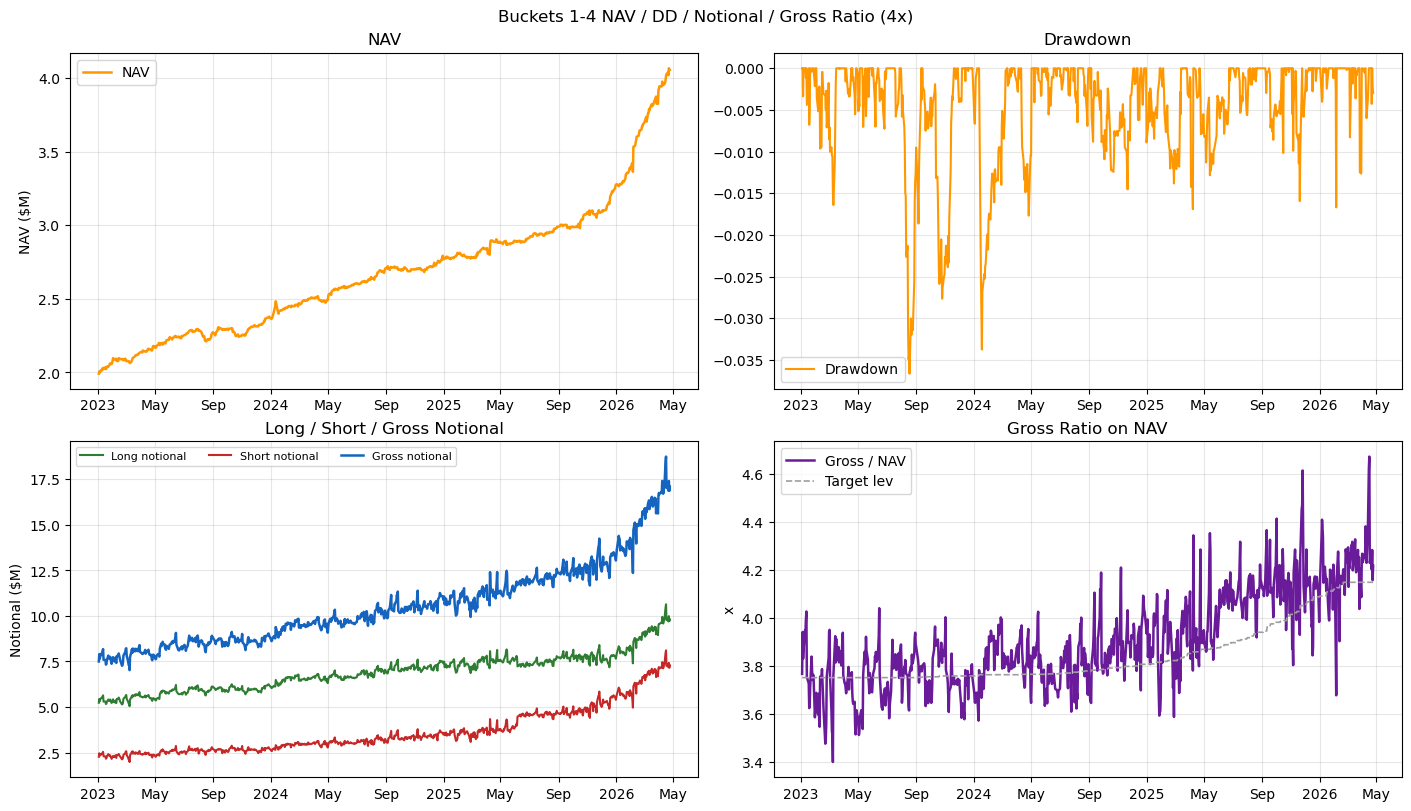

Gross/NAV stats @ 4x | mean=3.91x  median=3.87x  min=3.40x  max=4.67x


In [310]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

ref = max(LEVERAGE_RUNS)
bt = ALL_BT[ref].copy().sort_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 8), layout="constrained")
fig.suptitle(f"Buckets 1-4 NAV / DD / Notional / Gross Ratio ({ref}x)")

# --- NAV ---
ax = axes[0, 0]
dc_nav = bt["nav"]
ax.plot(dc_nav.index, dc_nav / 1e6, label="NAV", color="#FF9800", lw=1.8)
ax.set_ylabel("NAV ($M)")
ax.set_title("NAV")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Drawdown ---
ax = axes[0, 1]
dd_dc = (dc_nav - dc_nav.cummax()) / dc_nav.cummax()
ax.plot(dd_dc.index, dd_dc, label="Drawdown", color="#FF9800", lw=1.5)
ax.set_title("Drawdown")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Long / Short / Gross notional ---
ax = axes[1, 0]
long_n = pd.to_numeric(bt.get("long_notional"), errors="coerce")
short_n = pd.to_numeric(bt.get("short_notional"), errors="coerce")  # stored as positive in this notebook
gross_n = pd.to_numeric(bt.get("gross_notional"), errors="coerce")

ax.plot(bt.index, long_n / 1e6, label="Long notional", lw=1.5, color="#2E7D32")
ax.plot(bt.index, short_n / 1e6, label="Short notional", lw=1.5, color="#C62828")
ax.plot(bt.index, gross_n / 1e6, label="Gross notional", lw=1.8, color="#1565C0")
ax.set_ylabel("Notional ($M)")
ax.set_title("Long / Short / Gross Notional")
ax.legend(ncol=3, fontsize=8)
ax.grid(True, alpha=0.3)

# --- Gross ratio on NAV (gross leverage) ---
ax = axes[1, 1]
gross_ratio = np.where(dc_nav > 0, gross_n / dc_nav, np.nan)
ax.plot(bt.index, gross_ratio, label="Gross / NAV", lw=1.8, color="#6A1B9A")
if "target_lev" in bt.columns:
    ax.plot(bt.index, pd.to_numeric(bt["target_lev"], errors="coerce"),
            label="Target lev", lw=1.2, ls="--", color="#9E9E9E")
ax.set_ylabel("x")
ax.set_title("Gross Ratio on NAV")
ax.legend()
ax.grid(True, alpha=0.3)

for ax in axes.flat:
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

plt.show()

# quick summary print
print(
    f"Gross/NAV stats @ {ref}x | "
    f"mean={np.nanmean(gross_ratio):.2f}x  "
    f"median={np.nanmedian(gross_ratio):.2f}x  "
    f"min={np.nanmin(gross_ratio):.2f}x  "
    f"max={np.nanmax(gross_ratio):.2f}x"
)

## Buckets 1-4 -- exposure and PnL by pair / ETF

For each bucket: **stacked gross notional** by name (top panel), and **cumulative pair net PnL** for every name in that bucket plus a **thick line = sum of daily net PnL across all names** (entire-bucket cumulative net). Bucket tags match the backtest engine order: B3 names, then B4 `sizing_slice`, then whitelist, then core screener.


Buckets 1-4 pair-level charts (stacked gross + per-pair cumulative net + bucket total) @ 4x


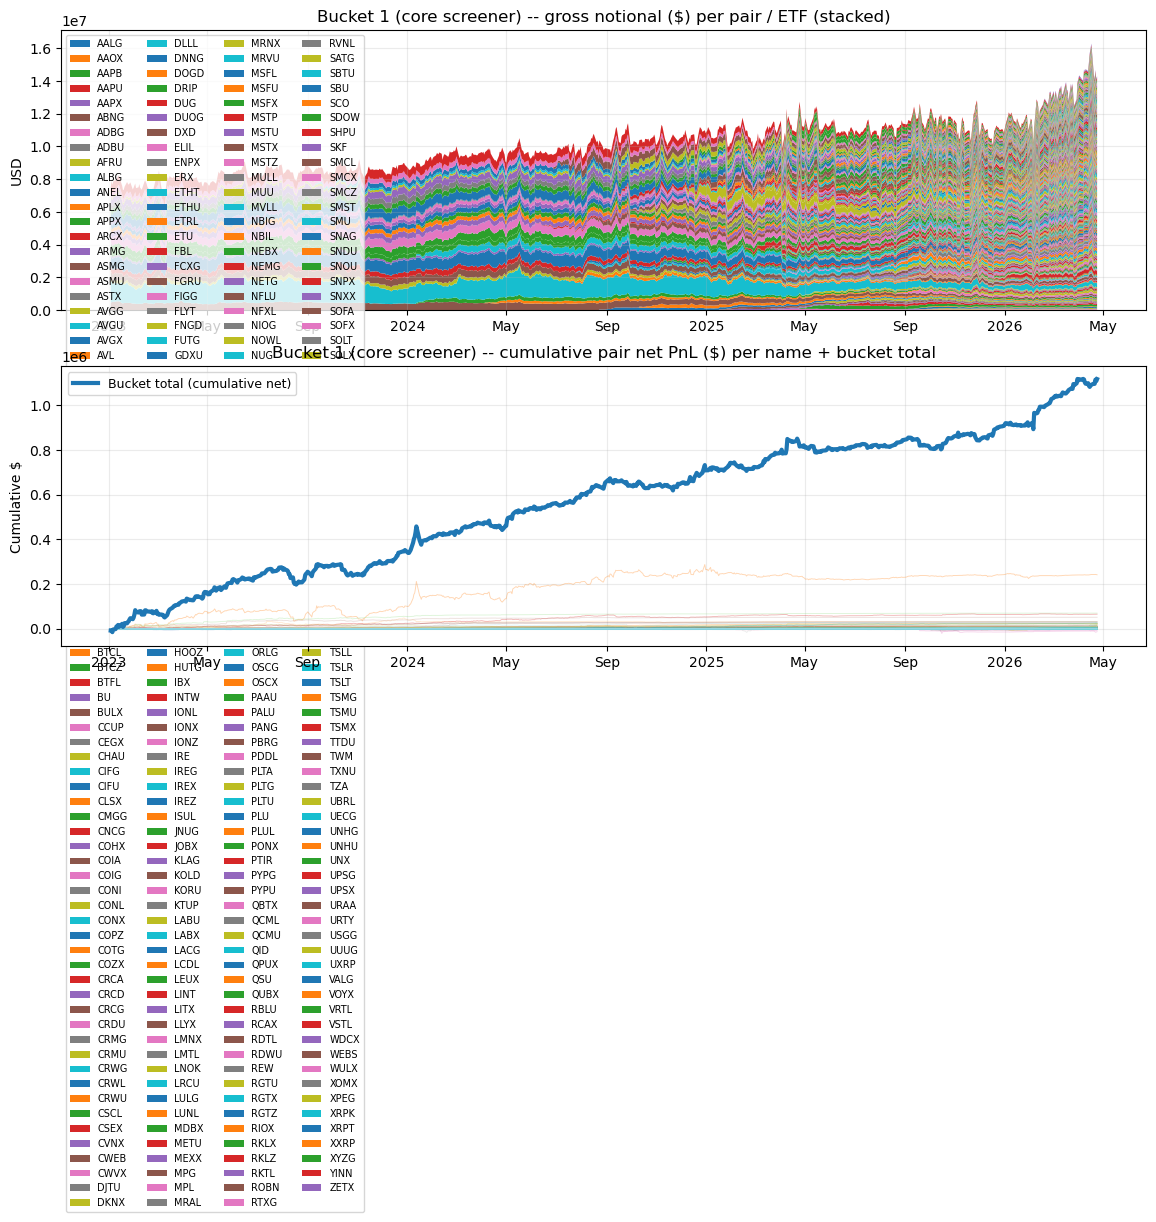

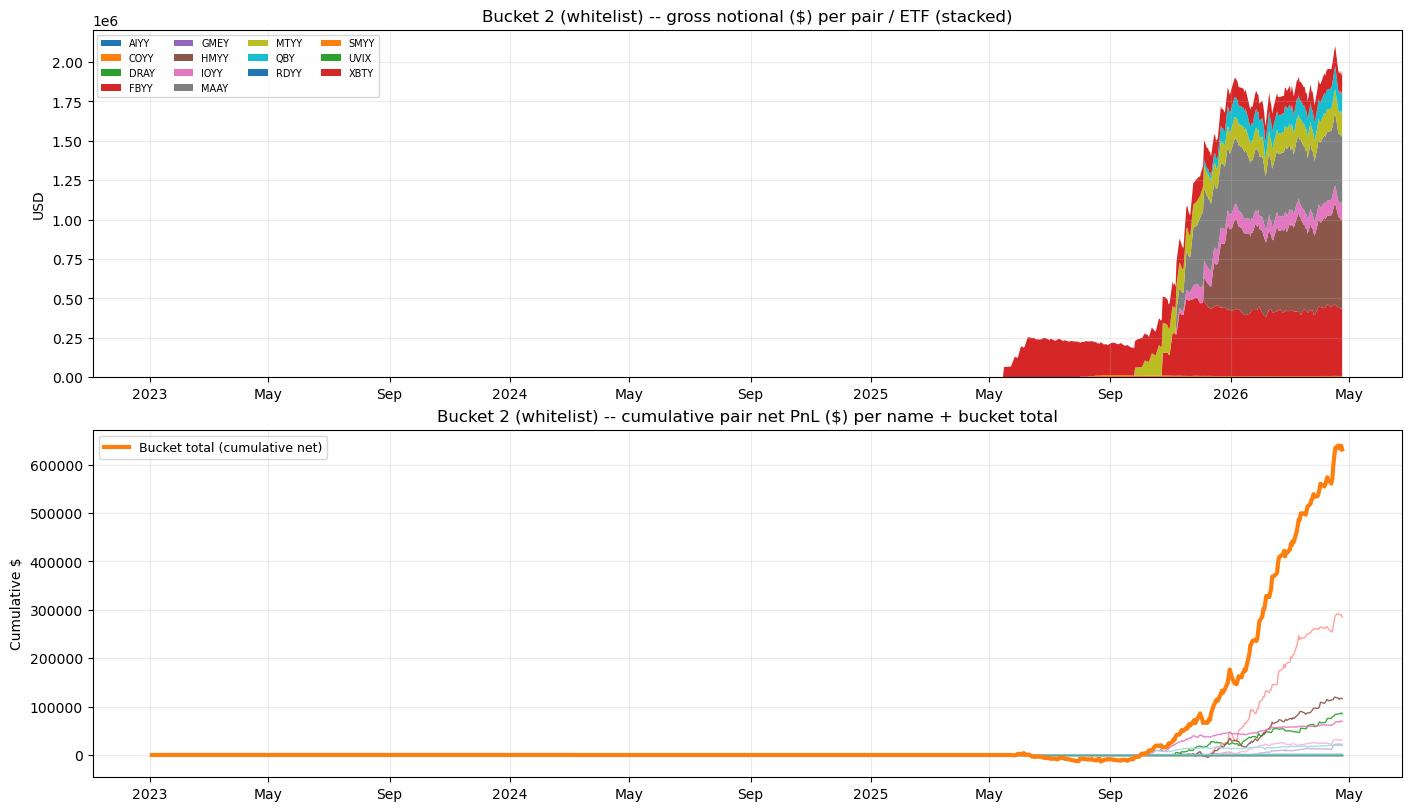

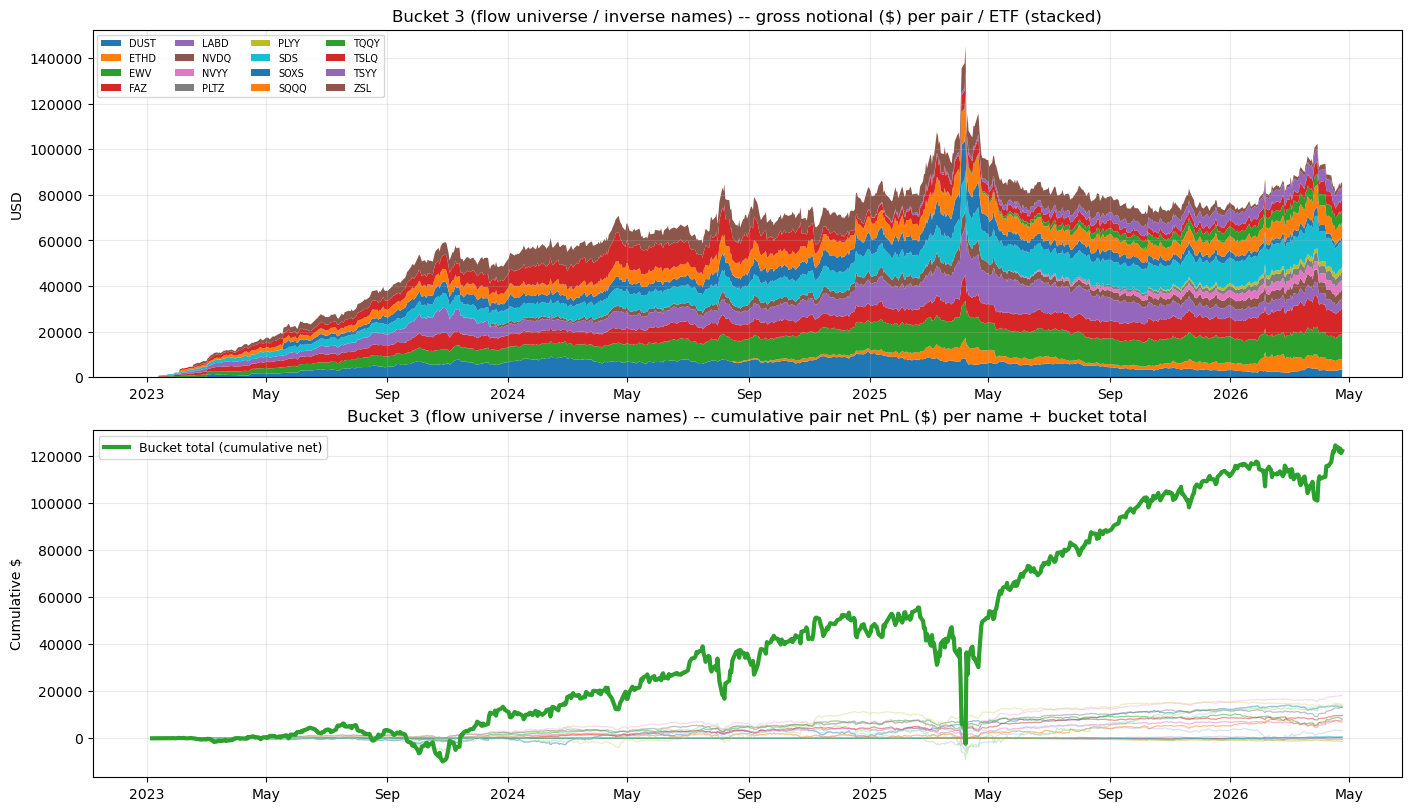

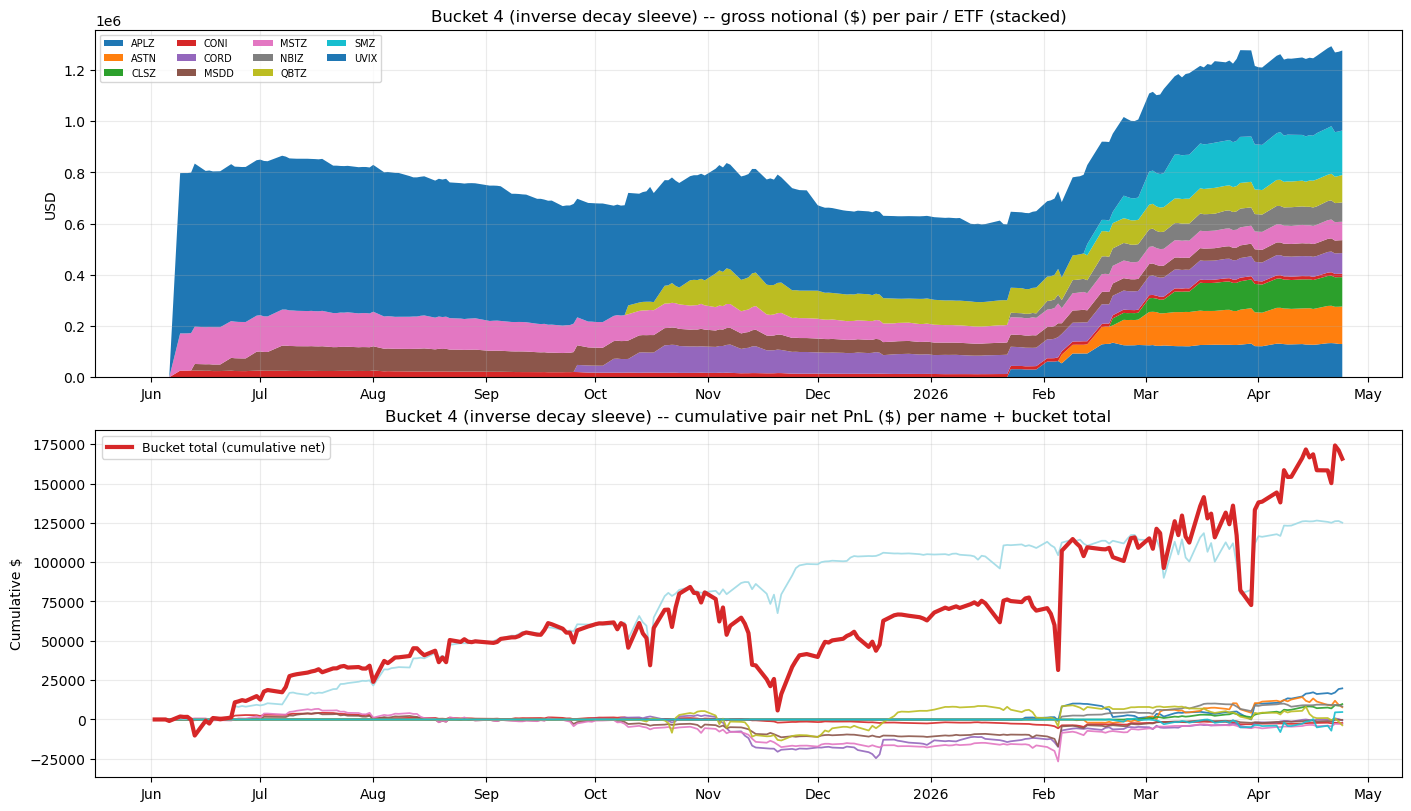

In [306]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd


def _plot_norm_sym(x: str) -> str:
    return str(x).upper().strip().replace(".", "-")


def _runtime_bucket_col(pdf: pd.DataFrame) -> pd.Series:
    """Match diagnostics / engine: B3 ETF set -> B3; B4 sizing_slice -> B4; whitelist -> B2; else core (B1)."""
    b3 = {_plot_norm_sym(x) for x in (globals().get("BUCKET3_ETFS") or set())}
    wl = {_plot_norm_sym(x) for x in (globals().get("WHITELIST_ETFS") or set())}
    ne = pdf["etf"].map(_plot_norm_sym)
    ss = pdf["sizing_slice"].fillna("").astype(str).str.strip()
    is_b3 = ne.isin(b3)
    is_b4 = ss.eq("bucket_4_inverse_decay")
    is_wl = ne.isin(wl)
    out = pd.Series("bucket_1_core_screener", index=pdf.index, dtype=object)
    out.loc[is_b3] = "bucket_3_inverse"
    out.loc[~is_b3 & is_b4] = "bucket_4_inverse_decay"
    out.loc[~is_b3 & ~is_b4 & is_wl] = "bucket_2_whitelist"
    return out


BUCKET_SPECS = [
    ("bucket_1_core_screener", "Bucket 1 (core screener)", "#1f77b4"),
    ("bucket_2_whitelist", "Bucket 2 (whitelist)", "#ff7f0e"),
    ("bucket_3_inverse", "Bucket 3 (flow universe / inverse names)", "#2ca02c"),
    ("bucket_4_inverse_decay", "Bucket 4 (inverse decay sleeve)", "#d62728"),
]


def _plot_bucket_pair_charts(sub: pd.DataFrame, title: str, total_color: str) -> None:
    """Stacked gross notional per name/ETF; cumulative net per pair plus thick bucket-total line."""
    if sub.empty:
        print(f"  (skip) {title}: no pair-days in ALL_PAIR_DAILY for this run.")
        return
    sub = sub.copy()
    sub["date"] = pd.to_datetime(sub["date"])
    piv_g = (
        sub.pivot_table(index="date", columns="etf", values="gross_notional_usd", aggfunc="sum")
        .sort_index()
        .fillna(0.0)
    )
    net_col = "daily_pair_net_pnl_usd"
    if net_col not in sub.columns:
        print(f"  (skip) {title}: missing `{net_col}`")
        return
    sub["_net"] = pd.to_numeric(sub[net_col], errors="coerce").fillna(0.0)
    piv_n = (
        sub.pivot_table(index="date", columns="etf", values="_net", aggfunc="sum")
        .sort_index()
        .fillna(0.0)
    )
    cols = sorted(set(piv_g.columns) | set(piv_n.columns), key=str)
    piv_g = piv_g.reindex(columns=cols, fill_value=0.0)
    piv_n = piv_n.reindex(columns=cols, fill_value=0.0)
    cum_n = piv_n.cumsum()
    daily_net_total = piv_n.sum(axis=1)
    cum_net_total = daily_net_total.cumsum()
    if cum_n.shape[1] == 0:
        print(f"  (skip) {title}: no per-name net PnL after pivot")
        return

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), layout="constrained")

    if piv_g.shape[1] > 0:
        axes[0].stackplot(
            piv_g.index,
            *[piv_g[c] for c in piv_g.columns],
            labels=[str(c) for c in piv_g.columns],
        )
        axes[0].legend(loc="upper left", ncol=4, fontsize=7)
    else:
        axes[0].text(
            0.5,
            0.5,
            "No gross_notional_usd columns",
            ha="center",
            va="center",
            transform=axes[0].transAxes,
        )
    axes[0].set_title(f"{title} -- gross notional ($) per pair / ETF (stacked)")
    axes[0].set_ylabel("USD")
    axes[0].grid(True, alpha=0.25)

    n = int(cum_n.shape[1])
    lw = float(max(0.65, min(1.6, 14.0 / max(n, 1))))
    alpha = 0.9 if n <= 14 else (0.32 if n > 90 else 0.5)
    colors = plt.cm.tab20(np.linspace(0, 1, max(n, 1)))
    for i, col in enumerate(cum_n.columns):
        axes[1].plot(
            cum_n.index,
            cum_n[col],
            lw=lw,
            alpha=alpha,
            color=colors[i % len(colors)],
            label=None,
        )
    axes[1].plot(
        cum_net_total.index,
        cum_net_total.values,
        color=total_color,
        lw=3.0,
        label="Bucket total (cumulative net)",
        zorder=20,
    )
    axes[1].set_title(f"{title} -- cumulative pair net PnL ($) per name + bucket total")
    axes[1].set_ylabel("Cumulative $")
    axes[1].legend(loc="upper left", fontsize=9)
    axes[1].grid(True, alpha=0.25)
    for ax in axes:
        ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    plt.show()


ref = max(LEVERAGE_RUNS)
pdf0 = ALL_PAIR_DAILY.get(ref)
if pdf0 is None or pdf0.empty:
    print("Run engine first (ALL_PAIR_DAILY empty).")
else:
    pdf = pdf0.copy()
    if "sizing_slice" not in pdf.columns:
        pdf["sizing_slice"] = ""
    pdf["sizing_slice"] = pdf["sizing_slice"].fillna("").astype(str)
    pdf["_bucket"] = _runtime_bucket_col(pdf)
    print(f"Buckets 1-4 pair-level charts (stacked gross + per-pair cumulative net + bucket total) @ {ref}x")
    for tag, title, col in BUCKET_SPECS:
        _plot_bucket_pair_charts(pdf.loc[pdf["_bucket"].eq(tag)].copy(), title, col)


## NAV Jump Attribution

Ranks the largest absolute daily NAV moves and estimates top pair-level contributors on those days using lagged pair gross and pair spread returns.


In [307]:
ref = max(LEVERAGE_RUNS)

if "UNIVERSE" not in globals() or len(UNIVERSE) == 0:
    if "CANDIDATES" in globals() and "INCEPTION" in globals():
        UNIVERSE = [(e, u, b) for e, u, b in CANDIDATES if (e, u) in INCEPTION]
        UNIVERSE.sort(key=lambda x: INCEPTION[(x[0], x[1])])
        print(f"[UNIVERSE] Rebuilt from CANDIDATES+INCEPTION: {len(UNIVERSE)} pairs")
    else:
        raise RuntimeError("Run universe setup cells first: CANDIDATES + INCEPTION/UNIVERSE are missing.")

beta_map = {e: abs(float(b)) for e, u, b in UNIVERSE}

def _build_pair_contrib_usd(pair_gross_df: pd.DataFrame) -> pd.DataFrame:
    if pair_gross_df is None or pair_gross_df.empty:
        return pd.DataFrame()

    idx = pair_gross_df.index
    contrib = pd.DataFrame(index=idx)

    for col in pair_gross_df.columns:
        if "/" not in col:
            continue
        und, etf = col.split("/", 1)
        if und not in PRICES or etf not in PRICES:
            continue

        pu = PRICES[und].reindex(idx).ffill()
        pe = PRICES[etf].reindex(idx).ffill()
        if pu.isna().all() or pe.isna().all():
            continue

        ru = pu.pct_change().fillna(0.0)
        re = pe.pct_change().fillna(0.0)

        babs = max(1e-9, beta_map.get(etf, 2.0))
        hr = 1.0 / babs
        long_frac = 1.0 / (1.0 + hr)
        short_frac = hr / (1.0 + hr)

        pair_ret = long_frac * ru - short_frac * re
        lag_gross = pair_gross_df[col].shift(1).fillna(0.0)
        contrib[col] = lag_gross * pair_ret

    return contrib


def _print_jump_attribution(label: str, bt: pd.DataFrame, pair_contrib: pd.DataFrame, top_n_days: int = 8, top_n_pairs: int = 5):
    nav = bt["nav"].astype(float)
    nav_ret = nav.pct_change().dropna()
    nav_pnl = nav.diff().fillna(0.0)

    top_days = nav_ret.abs().sort_values(ascending=False).head(top_n_days)

    print(f"\n{'='*78}")
    print(f"{label} — Top {top_n_days} absolute daily NAV moves")
    print(f"{'='*78}")
    for d in top_days.index:
        print(f"{d.date()}  NAV ret={nav_ret.loc[d]:+6.2%}  NAV pnl=${nav_pnl.loc[d]:+,.0f}")

    print(f"\n{label} — Pair attribution on jump days (approx, lag gross × spread return)")
    print(f"{'-'*78}")
    for d in top_days.index:
        if d not in pair_contrib.index:
            continue
        c = pair_contrib.loc[d].dropna()
        if c.empty:
            continue
        top_pairs = c.reindex(c.abs().sort_values(ascending=False).head(top_n_pairs).index)

        print(f"\n{d.date()}  NAV ret={nav_ret.loc[d]:+6.2%}  NAV pnl=${nav_pnl.loc[d]:+,.0f}")
        for pair, v in top_pairs.items():
            print(f"  {pair:>16s}  contrib=${v:+,.0f}")


dc_bt = ALL_BT[ref]
dc_contrib = _build_pair_contrib_usd(ALL_PAIR_GROSS[ref])

_print_jump_attribution("Diamond Creek Fund", dc_bt, dc_contrib)



Diamond Creek Fund — Top 8 absolute daily NAV moves
2026-02-06  NAV ret=+5.06%  NAV pnl=$+170,202
2024-01-16  NAV ret=-2.55%  NAV pnl=$-63,402
2026-03-31  NAV ret=+2.45%  NAV pnl=$+93,612
2025-04-09  NAV ret=+2.03%  NAV pnl=$+56,755
2026-03-09  NAV ret=+1.56%  NAV pnl=$+57,910
2025-10-17  NAV ret=+1.54%  NAV pnl=$+46,018
2024-01-08  NAV ret=+1.46%  NAV pnl=$+34,671
2026-02-05  NAV ret=-1.40%  NAV pnl=$-47,745

Diamond Creek Fund — Pair attribution on jump days (approx, lag gross × spread return)
------------------------------------------------------------------------------

2026-02-06  NAV ret=+5.06%  NAV pnl=$+170,202
         QBTS/QBTZ  contrib=$+27,435
         MSTR/MSTZ  contrib=$+26,942
         SVIX/UVIX  contrib=$+23,781
         APLD/APLZ  contrib=$+21,596
         CRWV/CORD  contrib=$+21,434

2024-01-16  NAV ret=-2.55%  NAV pnl=$-63,402
          UNG/BOIL  contrib=$-63,541
         BABA/BABX  contrib=$-1,320
         NVDA/NVDU  contrib=$+1,000
         NVDA/NVDL  contrib=$+99

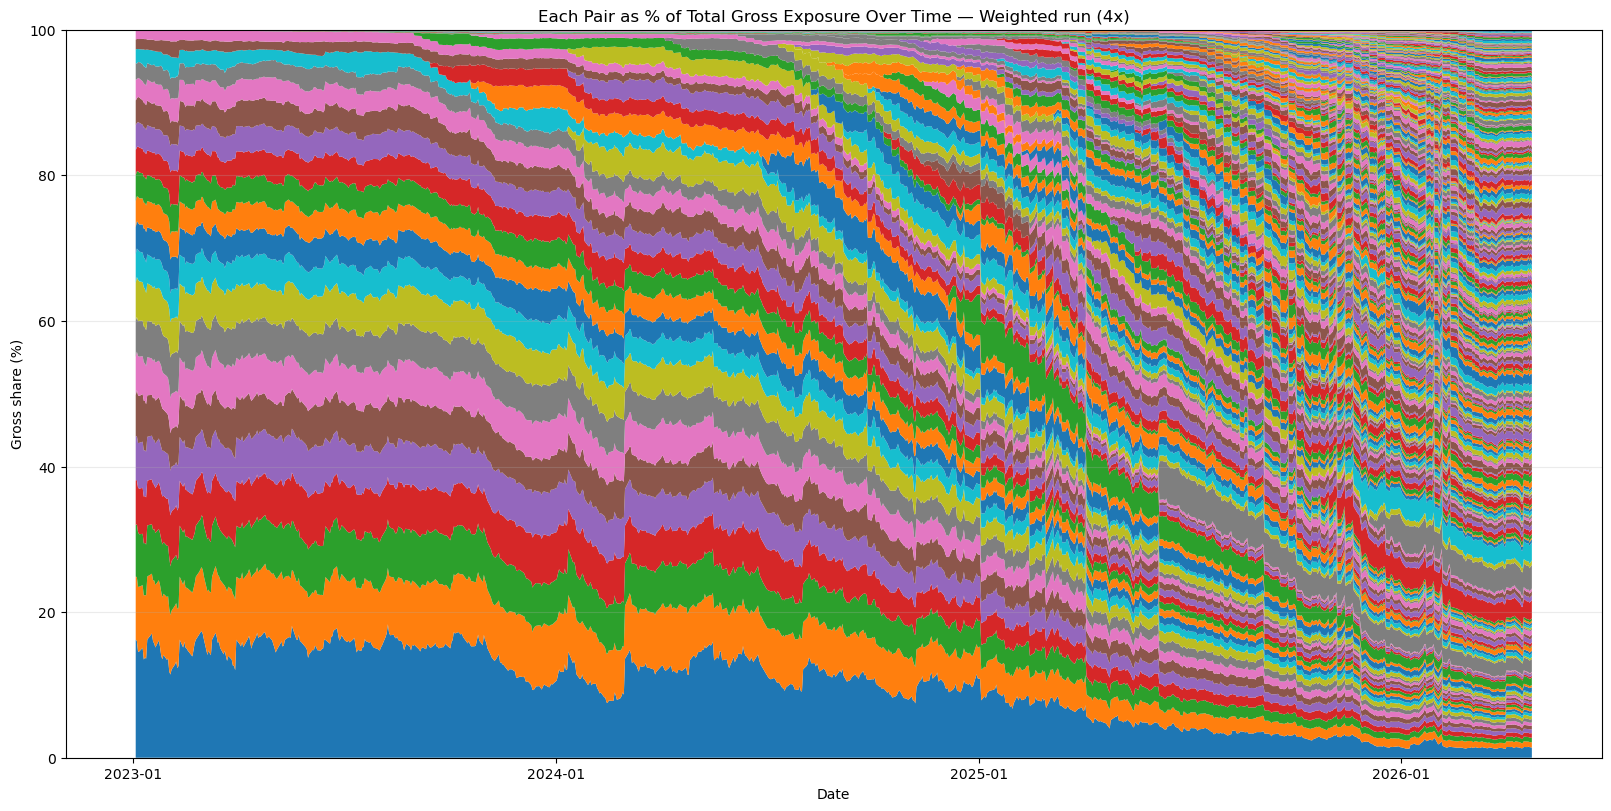

Pairs plotted: 353 | Date range: 2023-01-03 -> 2026-04-24


In [308]:
# ---- Pair gross share over time (% of total gross; each pair) ----
# Uses the most recent weighted run by default.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

if "ALL_PAIR_GROSS" in globals() and isinstance(ALL_PAIR_GROSS, dict) and len(ALL_PAIR_GROSS) > 0:
    ref_lev = max(ALL_PAIR_GROSS)
    gross_df = ALL_PAIR_GROSS[ref_lev].copy()
    run_label = f"Weighted run ({ref_lev}x)"
elif "EW_PAIR_GROSS" in globals() and isinstance(EW_PAIR_GROSS, dict) and len(EW_PAIR_GROSS) > 0:
    ref_lev = max(EW_PAIR_GROSS)
    gross_df = EW_PAIR_GROSS[ref_lev].copy()
    run_label = f"Equal-weight run ({ref_lev}x)"
else:
    raise RuntimeError("No pair gross time series found. Run a backtest cell first.")

if gross_df is None or gross_df.empty:
    raise RuntimeError("Pair gross time series is empty.")

# Ensure datetime index + numeric matrix.
gross_df = gross_df.copy()
gross_df.index = pd.to_datetime(gross_df.index)
gross_df = gross_df.apply(pd.to_numeric, errors="coerce").fillna(0.0)

# % share of total gross exposure each day.
total_gross = gross_df.sum(axis=1).replace(0.0, np.nan)
pair_gross_pct = gross_df.div(total_gross, axis=0).fillna(0.0) * 100.0

# Sort pairs for a stable stacked ordering (largest average share at bottom).
pair_order = pair_gross_pct.mean(axis=0).sort_values(ascending=False).index.tolist()
pair_gross_pct = pair_gross_pct[pair_order]

fig, ax = plt.subplots(figsize=(16, 8), layout="constrained")
ax.stackplot(pair_gross_pct.index, pair_gross_pct.T.values, linewidth=0)
ax.set_title(f"Each Pair as % of Total Gross Exposure Over Time — {run_label}")
ax.set_ylabel("Gross share (%)")
ax.set_xlabel("Date")
ax.set_ylim(0, 100)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.grid(axis="y", alpha=0.25)
plt.show()

print(f"Pairs plotted: {pair_gross_pct.shape[1]} | Date range: {pair_gross_pct.index.min().date()} -> {pair_gross_pct.index.max().date()}")

In [309]:
print("Pairs by average gross share (%):")
pair_gross_pct.mean().sort_values(ascending=False).head(50)

Pairs by average gross share (%):


UNG/BOIL      9.441806
GDX/GDXU      5.392906
FXI/YINN      4.270321
SOXX/SOXL     3.890363
EWY/KORU      3.736368
BABA/BABX     3.428247
GDXJ/JNUG     3.256487
QQQ/TQQQ      3.137166
KWEB/CWEB     3.130188
EWW/MEXX      2.423109
ARKK/TARK     2.328784
XOP/GUSH      2.223251
IWM/URTY      2.207946
META/FBL      2.197731
SPY/SPXL      2.159245
GDX/NUGT      2.103025
MSFT/MSFU     1.818338
NVDA/NVDL     1.495295
GOOGL/GOOX    1.415757
COIN/CONL     1.286334
URA/URAA      1.227293
TSLA/TSLT     1.210747
NVO/NVOX      1.127719
NVDA/NVDU     0.989797
MSFT/MSFX     0.964013
TSLA/TSLL     0.873637
GOOGL/GGLL    0.863473
SVIX/UVIX     0.851419
IBIT/BITX     0.839436
UBER/UBRL     0.791737
LLY/LLYX      0.646979
SMCI/SMCL     0.643271
TSLA/TSLR     0.622553
MU/MUU        0.552577
INTC/INTW     0.506663
MU/MULL       0.479271
DELL/DLLL     0.478985
IBIT/BITU     0.472353
IBIT/BTCL     0.458742
NFLX/NFLU     0.455227
NFLX/NFXL     0.435945
PLTR/PTIR     0.427422
AVGO/AVL      0.422782
META/FBYY  